# Conditional Generative Model for Radio Galaxy Projections

Learns to generate synthetic 89×89 radio galaxy images conditioned on morphology labels.

**Pipeline:**
```
class label y  →  NSF sample z ∈ ℝ^d  →  FlowMatchingUNet  →  89×89 image
```

**Two components trained sequentially:**

| Component | Input | Output | Loss |
|-----------|-------|--------|------|
| **FlowMatchingUNet** | BYOL projection z | 89×89 image | flow-matching MSE |
| **Conditional NSF** (`zuko.NSF`) | class label y | projection z ~ p(z\|y) | negative log-likelihood |

At generation time: sample z from the NSF conditioned on a class label, decode with the U-Net.

## 1. Imports

In [18]:
import sys
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import zuko
import umap
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

## 2. Configuration

Edit the values below before running the rest of the notebook.

| Key | Description |
|-----|-------------|
| `base_dir` | BYOL run output directory — must contain `byol_model_best.pt` and saved projections |
| `label_subset` | Which LoTSS label group to condition on (see table below) |
| `use_projections` | `True` → use PCA/MLP projection (256-dim); `False` → raw encoder features |

**Label subsets:**

| `label_subset` | Columns | Classes |
|----------------|---------|---------|
| `"classical"` | 0–1 | FRI, FRII |
| `"classical_pure"` | 0–1 | FRI, FRII (unambiguous only) |
| `"initial"` | 0–4 | FRI, FRII, Hybrids, Spirals, Relaxed doubles |
| `"initial_pure"` | 0–4 | same, single-label sources only |
| `"morphology"` | 5–14 | C-curv … Restarted |
| `"environment"` | 16–19 | Cluster, Merger, Diffuse, Unknown |


In [19]:
CONFIG = {
    # Point to the run output directory (data/ subdir is auto-detected; embeddings/ also supported)
    "base_dir":        ROOT / "outputs/run_cnxt_pca_pond_step_wd_20260507_1151",
    # generative_dir: path to a pre-trained generative run (decoder.pt + nsf.pt).
    #   Set to None to train from scratch instead.
    "generative_dir":  ROOT / "outputs/run_cnxt_pca_pond_step_wd_20260507_1151/generative/flow_initial_20260507_1437",
    # label_subset: 'classical' | 'classical_pure' | 'initial' | 'initial_pure' |
    #               'environment' | 'derived' | 'morphology' | 'all' | 'pure'
    # or a custom list of int indices into ALL_CLASS_NAMES
    "label_subset":    "initial",
    # ── Decoder ───────────────────────────────────────────────────────────────
    # use_projections: True  → decoder and NSF both operate on the PCA/MLP projection
    #                          (lower-dim, semantically rich, consistent with BYOL training)
    #                  False → decoder uses raw encoder features (higher-dim)
    "use_projections": True,
    "flow_n_steps":    20,          # Euler integration steps at generation time
    # ── Training ──────────────────────────────────────────────────────────────
    "flow_epochs":     200,
    "decoder_epochs":  300,
    "decoder_lr":      1e-4,
    "decoder_patience": 40,
    "batch_size":      256,
    "lr":              3e-4,
    "n_flow_transforms": 8,
    "seed":            42,
    # ── Regularisation ────────────────────────────────────────────────────────
    "decoder_weight_decay": 1e-4,
    "flow_weight_decay":    1e-5,
    "flow_feat_noise":      0.05,
}

# | label_subset      | Columns   | Classes                                                          |
# |-------------------|-----------|------------------------------------------------------------------|
# | "classical"       | 0–1       | FRI, FRII                                                        |
# | "classical_pure"  | 0–1       | FRI, FRII — sources with exactly one initial label               |
# | "initial"         | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles                     |
# | "initial_pure"    | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles — one initial label |
# | "environment"     | 16–19     | Cluster, Merger, Diffuse, Unknown                                |
# | "derived"         | computed  | Pure hybrid, FR hybrid, Curved FRI, Curved FRII, Straight+mHS   |
# | "morphology"      | 5–14      | C-curv … Restarted                                               |
# | "all"             | 0–19      | All 20 classes                                                   |
# | "pure"            | 0–19      | All 20 classes (single-label across all 20 only)                 |
#
# Derived label definitions (computed, not raw columns):
#   1. Pure hybrid    : col2 & ~col0 & ~col1
#   2. FR hybrid      : col2 & (col0 | col1)
#   3. Curved FRI     : col0 & (col5 | col6)
#   4. Curved FRII    : col1 & (col5 | col6)
#   5. Straight+mHS   : col10 & col11
LABEL_SUBSETS = {
    "classical":      [0, 1],
    "classical_pure": [0, 1],
    "initial":        list(range(0, 5)),
    "initial_pure":   list(range(0, 5)),
    "environment":    list(range(16, 20)),
    "derived":        None,  # computed from label combinations
    "morphology":     list(range(5, 15)),
    "all":            list(range(0, 20)),
    "pure":           list(range(0, 20)),
}

DERIVED_CLASS_NAMES = [
    'Pure hybrid',       # col2 & ~col0 & ~col1
    'FR hybrid',         # col2 & (col0 | col1)
    'Curved FRI',        # col0 & (col5 | col6)
    'Curved FRII',       # col1 & (col5 | col6)
    'Straight+multi-HS', # col10 & col11
]

ALL_CLASS_NAMES = [
    "FRI", "FRII", "Hybrids", "Spirals", "Relaxed doubles",        # 0-4  initial
    "C-curv", "S-curv", "Misalign", "Wings", "X-shaped",           # 5-9  morphology
    "Straight jets", "Multi hotspots", "Cont. jets", "Banding",    # 10-13
    "One-sided", "Restarted",                                       # 14-15
    "Cluster", "Merger", "Diffuse", "Unknown",                      # 16-19 environment
]

print("Config loaded.")
print(f"  use_projections: {CONFIG['use_projections']}")
print(f"  Label subset:    {CONFIG['label_subset']}")
print(f"  Base dir:        {CONFIG['base_dir']}")


Config loaded.
  use_projections: True
  Label subset:    initial
  Base dir:        /users/mbredber/p3_SUPLAT/outputs/run_cnxt_pca_pond_step_wd_20260507_1151


## 3. Load Projections (catalogue split)

Loads projections from `<base_dir>/projections/lotss_projections.npy` and
`lotss_splits.npy`, which were generated by `embed_and_umap.py --catalogue`.
The train/val/test split (64 / 16 / 20 %) is the same as `classification.ipynb`
— both read from `catalogues/lotss_initial_all_split.json`.

Full 20-dim labels are loaded from `data/preprocessed/lotss/labels_filtered.npy`
indexed by the catalogue sidecar, then sliced by `label_subset`.


In [ ]:
import json as _json

_base    = Path(CONFIG["base_dir"])
proj_dir = _base / "projections"

# ── Load catalogue-aligned projections ────────────────────────────────────────
_all_z     = np.load(proj_dir / "lotss_projections.npy").astype(np.float32)
_split_ids = np.load(proj_dir / "lotss_splits.npy")

# ── Catalogue sidecar — same split used by classification.ipynb ───────────────
_cat_sidecar = ROOT / "catalogues/lotss_initial_all_split.json"
with open(_cat_sidecar) as _f:
    _sidecar = _json.load(_f)
_train_idx = np.array(_sidecar["lotss"]["train"])
_val_idx   = np.array(_sidecar["lotss"]["val"])
_test_idx  = np.array(_sidecar["lotss"]["test"])

# ── Full 20-dim labels aligned to catalogue split order ───────────────────────
_all_lbl = np.load(ROOT / "data/preprocessed/lotss/labels_filtered.npy").astype(np.float32)
train_lbl_full = _all_lbl[_train_idx]
val_lbl_full   = _all_lbl[_val_idx]
test_lbl_full  = _all_lbl[_test_idx]

# ── Projections split by catalogue membership ─────────────────────────────────
train_z = _all_z[_split_ids == 0]
val_z   = _all_z[_split_ids == 1]
test_z  = _all_z[_split_ids == 2]

# Select label subset
label_subset = CONFIG["label_subset"]
if isinstance(label_subset, list):
    label_idx = label_subset
else:
    label_idx = LABEL_SUBSETS[label_subset]

# For "derived": compute 5 boolean combination columns
def _make_derived(y):
    c = lambda i: y[:, i].astype(bool)
    return np.stack([
        ( c(2) & ~c(0) & ~c(1)).astype(np.float32),   # Pure hybrid
        ( c(2) &  (c(0) | c(1))).astype(np.float32),  # FR hybrid
        ( c(0) &  (c(5) | c(6))).astype(np.float32),  # Curved FRI
        ( c(1) &  (c(5) | c(6))).astype(np.float32),  # Curved FRII
        (c(10) &   c(11)).astype(np.float32),          # Straight + multi-HS
    ], axis=1)

if label_subset == "derived":
    train_y = _make_derived(train_lbl_full)
    val_y   = _make_derived(val_lbl_full)
    test_y  = _make_derived(test_lbl_full)
    label_names_subset = DERIVED_CLASS_NAMES
else:
    train_y = train_lbl_full[:, label_idx]
    val_y   = val_lbl_full[:, label_idx]
    test_y  = test_lbl_full[:, label_idx]
    label_names_subset = [ALL_CLASS_NAMES[i] for i in label_idx]

n_labels = len(label_names_subset)

# Pure filtering — always define masks (all-True by default)
keep_train_mask = np.ones(len(train_lbl_full), dtype=bool)
keep_val_mask   = np.ones(len(val_lbl_full),   dtype=bool)
keep_test_mask  = np.ones(len(test_lbl_full),  dtype=bool)

if label_subset == "pure":
    keep_train_mask = train_lbl_full.sum(axis=1) == 1
    keep_val_mask   = val_lbl_full.sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full.sum(axis=1)  == 1
    print(f"Pure filter (all 20)   : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")
elif label_subset in ("classical_pure", "initial_pure"):
    keep_train_mask = train_lbl_full[:, 0:5].sum(axis=1) == 1
    keep_val_mask   = val_lbl_full[:, 0:5].sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full[:, 0:5].sum(axis=1)  == 1
    print(f"Initial-pure filter    : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")

train_z, train_y = train_z[keep_train_mask], train_y[keep_train_mask]
val_z,   val_y   = val_z[keep_val_mask],     val_y[keep_val_mask]
test_z,  test_y  = test_z[keep_test_mask],   test_y[keep_test_mask]

print(f"Catalogue split: train={len(_train_idx)} | val={len(_val_idx)} | test={len(_test_idx)}")
print(f"Label subset ({n_labels}): {label_names_subset}")
print(f"Train z: {train_z.shape} | Val z: {val_z.shape} | Test z: {test_z.shape}")
print(f"Train labels: {train_y.shape}")
print(f"Label prevalence (train):\n",
      dict(zip(label_names_subset, train_y.mean(axis=0).round(3))))


## 4. Align Projections with Images

Loads raw images and the BYOL checkpoint. Image indices come from the
**catalogue sidecar** (`_train_idx`, `_val_idx`, `_test_idx`) loaded in Cell 6 —
the same split used by `classification.ipynb`.

Projections from Cell 6 are wrapped as tensors; no re-extraction is needed.

**Decoder conditioning** is controlled by `CONFIG["use_projections"]`:
- `True` (default) — use PCA/MLP projections as the conditioning vector `z`
- `False` — use raw encoder features instead (BYOL is required in that case)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

USE_PROJECTIONS = CONFIG.get("use_projections", True)

print("Loading images…")
all_images = np.load(ROOT / "data/preprocessed/lotss/images_filtered.npy")   # (N, 89, 89) uint8
all_labels = np.load(ROOT / "data/preprocessed/lotss/labels_filtered.npy")  # (N, 20) uint8
print(f"  Images: {all_images.shape}, dtype={all_images.dtype}")
print(f"  Labels: {all_labels.shape}, dtype={all_labels.dtype}")

base_dir  = Path(CONFIG["base_dir"])
ckpt_path = Path(CONFIG["byol_checkpoint"]) if "byol_checkpoint" in CONFIG \
            else base_dir / "byol_model_best.pt"

# ── Split indices from catalogue sidecar (loaded in Cell 6) ──────────────────
train_idx = _train_idx
val_idx   = _val_idx
test_idx  = _test_idx
print(f"Using catalogue split: train={len(train_idx)} | val={len(val_idx)} | test={len(test_idx)}")

def _strip_compile_prefix(sd):
    p = "_orig_mod."
    return {k[len(p):] if k.startswith(p) else k: v for k, v in sd.items()} \
           if any(k.startswith(p) for k in sd) else sd

def infer_model_type(sd):
    keys = set(sd.keys())
    if any("online_encoder.features.1.0.block.0.0.weight" in k for k in keys): return "efficientnet-b0"
    if any("online_encoder.features.1.0.block.0.weight"   in k for k in keys): return "convnext-tiny"
    if any("online_encoder.layer1.0.conv1.weight"         in k for k in keys):
        proj = sd.get("online_projector.net.0.weight")
        return "resnet50" if (proj is not None and proj.shape[1] == 2048) else "resnet18"
    if any("online_encoder.conv1.weight" in k for k in keys): return "convnet"
    return None

def infer_projection_config(sd):
    mode = "pca" if "online_projector.mean_" in sd else "mlp"
    pred_w = sd.get("online_predictor.net.0.weight")
    return mode, int(pred_w.shape[1]) if pred_w is not None else 256

def prepare_pca_model(model, sd):
    from suplat.models.byol_models import PCAProjection, PredictionHead
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if not isinstance(proj, PCAProjection): continue
        for buf in ("mean_", "components_", "active_mask_"):
            key = f"{prefix}.{buf}"
            if key in sd: proj.register_buffer(buf, sd[key].clone())
        proj._fitted = True
    if model.online_predictor is None and "online_predictor.net.0.weight" in sd:
        proj_dim = sd["online_predictor.net.0.weight"].shape[1]
        hidden_dim, bn_momentum = model._predictor_config
        model.online_predictor = PredictionHead(
            in_dim=proj_dim, hidden_dim=hidden_dim, out_dim=proj_dim, bn_momentum=bn_momentum)

def patch_missing_active_mask(model, sd):
    from suplat.models.byol_models import PCAProjection
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if isinstance(proj, PCAProjection) and not hasattr(proj, "active_mask_"):
            n = proj.mean_.shape[0]
            proj.register_buffer("active_mask_", torch.ones(n, dtype=torch.bool))
            print(f"  [PCA] {prefix}: patched active_mask_ ({n} features)")

def load_byol_from_checkpoint(path, device):
    from suplat.models.byol_models import (
        BYOLEfficient, BYOLEfficientNetB0, BYOLPretrainedBackbone,
        create_resnet18_backbone, create_resnet50_backbone, create_convnext_tiny_backbone,
    )
    ckpt = torch.load(path, map_location=device)
    sd   = _strip_compile_prefix(ckpt["model_state_dict"])
    model_type          = infer_model_type(sd)
    proj_mode, proj_dim = infer_projection_config(sd)
    print(f"  model_type: {model_type!r} | projection: {proj_mode!r} dim={proj_dim}")
    if   model_type == "convnet":         model = BYOLEfficient(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "efficientnet-b0": model = BYOLEfficientNetB0(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "resnet18":
        bb, enc = create_resnet18_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "resnet50":
        bb, enc = create_resnet50_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "convnext-tiny":
        bb, enc = create_convnext_tiny_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    else: raise ValueError(f"Could not detect model type from checkpoint")
    if proj_mode == "pca": prepare_pca_model(model, sd)
    model.load_state_dict(sd)
    if proj_mode == "pca": patch_missing_active_mask(model, sd)
    model.eval().to(device)
    for p in model.parameters(): p.requires_grad = False
    print(f"  BYOL loaded (epoch {ckpt['epoch']}, best_val_loss={ckpt.get('best_val_loss','?'):.4f})")
    return model

# BYOL is always loaded — needed for downstream generation/evaluation cells
print("Loading BYOL checkpoint…")
byol = load_byol_from_checkpoint(ckpt_path, device)

# ── Projections as torch tensors (from Cell 6) ────────────────────────────────
train_proj = torch.from_numpy(train_z.copy())
val_proj   = torch.from_numpy(val_z.copy())
test_proj  = torch.from_numpy(test_z.copy())

# ── Image tensors (needed for decoder training) ───────────────────────────────
# n_*: sized to match catalogue split after keep_*_mask from Cell 6
n_train, n_val, n_test = len(keep_train_mask), len(keep_val_mask), len(keep_test_mask)
train_imgs = torch.from_numpy(all_images[train_idx[:n_train]].astype(np.float32) / 255.0).unsqueeze(1)
val_imgs   = torch.from_numpy(all_images[val_idx[:n_val]  ].astype(np.float32)   / 255.0).unsqueeze(1)
test_imgs  = torch.from_numpy(all_images[test_idx[:n_test] ].astype(np.float32)  / 255.0).unsqueeze(1)

# ── Encoder features — only needed when use_projections=False ─────────────────
if not USE_PROJECTIONS:
    def _extract_feats(img_array, bs=128):
        imgs_t = torch.from_numpy(img_array.astype(np.float32) / 255.0).unsqueeze(1)
        out = []
        with torch.no_grad():
            for (x,) in DataLoader(TensorDataset(imgs_t), batch_size=bs):
                out.append(byol.online_encoder(x.to(device)).cpu())
        return torch.cat(out)
    print("Extracting raw encoder features for decoder…")
    _train_feats_raw = _extract_feats(all_images[train_idx])[:n_train]
    _val_feats_raw   = _extract_feats(all_images[val_idx])[:n_val]
    _test_feats_raw  = _extract_feats(all_images[test_idx])[:n_test]

# ── Apply label/pure filter mask from Cell 6 ──────────────────────────────────
train_imgs = train_imgs[keep_train_mask]
val_imgs   = val_imgs[keep_val_mask]
test_imgs  = test_imgs[keep_test_mask]
# (projections already filtered by Cell 6)

# ── Decoder conditioning: projections (default) or raw encoder features ────────
if USE_PROJECTIONS:
    train_feats = train_proj
    val_feats   = val_proj
    test_feats  = test_proj
    print("Decoder input: PCA/MLP projections")
else:
    train_feats = _train_feats_raw[keep_train_mask]
    val_feats   = _val_feats_raw[keep_val_mask]
    test_feats  = _test_feats_raw[keep_test_mask]
    print("Decoder input: raw encoder features")

print(f"\nSplit sizes (after filter) — train: {train_feats.shape[0]} | val: {val_feats.shape[0]} | test: {test_feats.shape[0]}")
print(f"Decoder input dim: {train_feats.shape[1]}  |  NSF input dim: {train_proj.shape[1]}")


## 5. Decoder — Flow Matching U-Net

The decoder is a **`FlowMatchingUNet`** that generates 89×89 images conditioned on a
BYOL projection `z`.

### Training: straight-line flow matching

A linear interpolation defines a probability path between Gaussian noise and the real image:

```
x_t = (1 − t) · x_noise  +  t · x_real       t ~ U[0, 1],  x_noise ~ N(0, 1)
```

The constant velocity along this path is `v* = x_real − x_noise`.  The U-Net is trained
to predict this velocity at any point along the path:

```
Loss = E_{t, x_real, x_noise} [ ‖ v_θ(x_t, t, z) − (x_real − x_noise) ‖² ]
```

Because the path is straight, a single Euler step is theoretically exact — in practice
20 steps are used to allow the network to correct errors.

### Architecture

```
x_t (1×89×89) ──┐
z   (d)    ──→  cond ──→ scale/shift at every residual block
t   (scalar) ──┘

Encoder:    Conv → ResBlock(C)   → stride-2 → ResBlock(2C) → stride-2 → ResBlock(4C) → stride-2
Bottleneck: ResBlock(8C) × 2
Decoder:    upsample → ResBlock(8C) ⊕ skip → upsample → ResBlock(4C) ⊕ skip → ...
Output:     GroupNorm → SiLU → Conv → velocity (1×89×89, unbounded)
```

`z` and a sinusoidal time embedding of `t` are concatenated and injected into every
residual block via **AdaIN-style scale+shift**, so morphology conditioning is applied
at all spatial scales.

In [22]:
class _SinusoidalEmbedding(nn.Module):
    # Sinusoidal time embedding for flow timestep t in [0, 1].
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1))
        x     = t[:, None] * freqs[None]
        return torch.cat([x.sin(), x.cos()], dim=-1)


class _CondResBlock(nn.Module):
    # Residual conv block: GroupNorm + AdaIN-style scale/shift from conditioning vector.
    def __init__(self, channels, cond_dim):
        super().__init__()
        g = min(8, channels)
        self.norm1 = nn.GroupNorm(g, channels)
        self.norm2 = nn.GroupNorm(g, channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.cond  = nn.Linear(cond_dim, 2 * channels)

    def forward(self, x, cond):
        scale, shift = self.cond(cond).chunk(2, dim=-1)
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = F.silu(self.norm2(h) * (1 + scale[..., None, None]) + shift[..., None, None])
        return x + self.conv2(h)


class FlowMatchingUNet(nn.Module):
    # Flow-matching velocity network: v_θ(x_t, t, z) → velocity field (B, 1, 89, 89).
    # Training loss: MSE( v_θ(x_t, t, z), x_real − x_noise )
    # Inference:     Euler ODE  x_{k+1} = x_k + (1/K) · v_θ(x_k, k/K, z)  from x_0 ~ N(0,1).
    IMG_SIZE = 89

    def __init__(self, z_dim, t_dim=128, base_ch=32):
        super().__init__()
        C        = base_ch
        cond_dim = z_dim + t_dim

        self.t_embed = nn.Sequential(
            _SinusoidalEmbedding(t_dim),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        self.in_conv = nn.Conv2d(1, C, 3, padding=1)
        self.res_e1  = _CondResBlock(C,    cond_dim)
        self.down1   = nn.Conv2d(C,   C*2, 3, stride=2, padding=1)
        self.res_e2  = _CondResBlock(C*2,  cond_dim)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)
        self.res_e3  = _CondResBlock(C*4,  cond_dim)
        self.down3   = nn.Conv2d(C*4, C*8, 3, stride=2, padding=1)
        self.res_m1  = _CondResBlock(C*8, cond_dim)
        self.res_m2  = _CondResBlock(C*8, cond_dim)
        self.up3     = nn.Conv2d(C*8, C*4, 3, padding=1)
        self.res_d3  = _CondResBlock(C*8, cond_dim)
        self.up2     = nn.Conv2d(C*8, C*2, 3, padding=1)
        self.res_d2  = _CondResBlock(C*4, cond_dim)
        self.up1     = nn.Conv2d(C*4, C,   3, padding=1)
        self.res_d1  = _CondResBlock(C*2, cond_dim)
        self.out_norm = nn.GroupNorm(min(8, C*2), C*2)
        self.out_conv = nn.Conv2d(C*2, 1, 3, padding=1)

    def forward(self, x_t, t, z):
        cond = torch.cat([z, self.t_embed(t)], dim=-1)
        h    = F.silu(self.in_conv(x_t))
        h1   = self.res_e1(h, cond)
        h2   = self.res_e2(F.silu(self.down1(h1)), cond)
        h3   = self.res_e3(F.silu(self.down2(h2)), cond)
        h    = F.silu(self.down3(h3))
        h    = self.res_m1(h, cond)
        h    = self.res_m2(h, cond)
        h    = F.silu(self.up3(F.interpolate(h, size=h3.shape[-2:], mode='nearest')))
        h    = self.res_d3(torch.cat([h, h3], dim=1), cond)
        h    = F.silu(self.up2(F.interpolate(h, size=h2.shape[-2:], mode='nearest')))
        h    = self.res_d2(torch.cat([h, h2], dim=1), cond)
        h    = F.silu(self.up1(F.interpolate(h, size=h1.shape[-2:], mode='nearest')))
        h    = self.res_d1(torch.cat([h, h1], dim=1), cond)
        return self.out_conv(F.silu(self.out_norm(h)))

    @torch.no_grad()
    def sample(self, z, n_steps=20):
        # Euler ODE: integrate velocity field from N(0,1) to image.
        self.eval()
        x  = torch.randn(z.shape[0], 1, self.IMG_SIZE, self.IMG_SIZE, device=z.device)
        dt = 1.0 / n_steps
        for i in range(n_steps):
            t = torch.full((z.shape[0],), i * dt, device=z.device)
            x = x + self(x, t, z) * dt
        return torch.clamp(x, 0.0, 1.0)


# Sanity check
_zdim = 192
_flow = FlowMatchingUNet(z_dim=_zdim, base_ch=32)
_x, _t, _z = torch.randn(4, 1, 89, 89), torch.rand(4), torch.randn(4, _zdim)
print(f"FlowMatchingUNet  velocity: {_flow(_x, _t, _z).shape} | params: {sum(p.numel() for p in _flow.parameters()):,}")
print(f"FlowMatchingUNet  sample:   {_flow.sample(_z, n_steps=2).shape}")
del _flow, _x, _t, _z

FlowMatchingUNet  velocity: torch.Size([4, 1, 89, 89]) | params: 5,962,913
FlowMatchingUNet  sample:   torch.Size([4, 1, 89, 89])


## 6. Load or Train Decoder

If `CONFIG["generative_dir"]` points to a pre-trained run, the decoder is loaded
from `decoder.pt` in that directory.  Otherwise it is trained from scratch.

**Loss** (straight-line flow matching):

```
x_t = (1 − t) · noise  +  t · x_real        t ~ U[0,1]
Loss = MSE( v_θ(x_t, t, z),  x_real − noise )
```

- **Optimiser**: Adam with cosine LR annealing
- **Early stopping**: patience = `CONFIG["decoder_patience"]`

In [23]:
torch.manual_seed(CONFIG["seed"])

# ── Resolve generative run directory ──────────────────────────────────────────
_gen_dir = Path(CONFIG["generative_dir"]) if CONFIG.get("generative_dir") else None
if _gen_dir is not None and not _gen_dir.exists():
    print(f"Warning: generative_dir not found: {_gen_dir}\n  → training from scratch")
    _gen_dir = None

FEAT_DIM     = train_feats.shape[1]
BASE_CH      = CONFIG.get("base_ch", 32)
FLOW_N_STEPS = CONFIG["flow_n_steps"]

print(f"Feat dim: {FEAT_DIM} | base_ch: {BASE_CH} | flow_n_steps: {FLOW_N_STEPS}")

if _gen_dir is not None:
    # ── Load pre-trained decoder ───────────────────────────────────────────────
    _ckpt = torch.load(_gen_dir / "decoder.pt", map_location=device, weights_only=False)
    decoder = FlowMatchingUNet(
        z_dim   = _ckpt["feat_dim"],
        base_ch = _ckpt["base_ch"],
    ).to(device)
    decoder.load_state_dict(_ckpt["model_state_dict"])
    decoder.eval()
    print(f"Loaded decoder from {_gen_dir.name}")
    print(f"  feat_dim={_ckpt['feat_dim']} | base_ch={_ckpt['base_ch']} "
          f"| best_val_loss={_ckpt['best_val_loss']:.4f} | stopped at epoch {_ckpt['epoch']+1}")
else:
    # ── Train decoder from scratch ─────────────────────────────────────────────
    DEC_LR       = CONFIG["decoder_lr"]
    DEC_WD       = CONFIG.get("decoder_weight_decay", 1e-4)
    DEC_EPOCHS   = CONFIG["decoder_epochs"]
    DEC_PATIENCE = CONFIG["decoder_patience"]
    bs           = CONFIG["batch_size"]

    decoder = FlowMatchingUNet(z_dim=FEAT_DIM, base_ch=BASE_CH).to(device)
    print(f"FlowMatchingUNet params: {sum(p.numel() for p in decoder.parameters()):,}")

    opt_dec   = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=DEC_WD)
    sched_dec = torch.optim.lr_scheduler.CosineAnnealingLR(opt_dec, T_max=DEC_EPOCHS)

    train_loader_dec = DataLoader(TensorDataset(train_feats, train_imgs),
                                  batch_size=bs, shuffle=True, drop_last=True)
    val_loader_dec   = DataLoader(TensorDataset(val_feats,   val_imgs),
                                  batch_size=bs, shuffle=False)

    dec_train_losses, dec_val_losses = [], []
    best_val_dec, best_state_dec, best_epoch_dec, patience_ctr = float("inf"), None, 0, 0

    for epoch in range(DEC_EPOCHS):
        decoder.train()
        tr_loss = 0.0
        for z_b, img_b in train_loader_dec:
            z_b, img_b = z_b.to(device), img_b.to(device)
            t     = torch.rand(img_b.shape[0], device=device)
            noise = torch.randn_like(img_b)
            x_t   = (1 - t[:, None, None, None]) * noise + t[:, None, None, None] * img_b
            loss  = F.mse_loss(decoder(x_t, t, z_b), img_b - noise)
            opt_dec.zero_grad(); loss.backward(); opt_dec.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader_dec)

        decoder.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for z_b, img_b in val_loader_dec:
                z_b, img_b = z_b.to(device), img_b.to(device)
                t     = torch.rand(img_b.shape[0], device=device)
                noise = torch.randn_like(img_b)
                x_t   = (1 - t[:, None, None, None]) * noise + t[:, None, None, None] * img_b
                vl_loss += F.mse_loss(decoder(x_t, t, z_b), img_b - noise).item()
        vl_loss /= len(val_loader_dec)

        dec_train_losses.append(tr_loss); dec_val_losses.append(vl_loss)
        sched_dec.step()

        if vl_loss < best_val_dec:
            best_val_dec, best_epoch_dec, patience_ctr = vl_loss, epoch, 0
            best_state_dec = copy.deepcopy(decoder.state_dict())
        else:
            patience_ctr += 1
            if patience_ctr >= DEC_PATIENCE:
                print(f"Early stopping at epoch {epoch+1} (patience={DEC_PATIENCE})")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{DEC_EPOCHS} "
                  f"| Train: {tr_loss:.4f} | Val: {vl_loss:.4f}"
                  f"{' *' if patience_ctr == 0 else ''}")

    decoder.load_state_dict(best_state_dec)
    print(f"\nBest epoch: {best_epoch_dec+1} | Best val loss: {best_val_dec:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(dec_train_losses, label="Train"); ax.plot(dec_val_losses, label="Val")
    ax.axvline(x=best_epoch_dec, color="red", linestyle="--", linewidth=1.2,
               label=f"Best epoch {best_epoch_dec+1}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Flow Matching MSE Loss")
    ax.set_title("Decoder Training Loss"); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"Best val loss: {best_val_dec:.4f}")

Feat dim: 192 | base_ch: 32 | flow_n_steps: 20
Loaded decoder from flow_initial_20260507_1437
  feat_dim=192 | base_ch=32 | best_val_loss=0.0483 | stopped at epoch 82


## 7. Conditional NSF — Neural Spline Flow

The **Neural Spline Flow** (`zuko.flows.NSF`) models the conditional distribution
`p(z | y)` over BYOL projections, where `y` is a binary morphology label vector.

### Architecture

Each of the `n_flow_transforms` coupling layers applies a monotone
**rational-quadratic spline** to a subset of dimensions.  The spline parameters
(knot positions, widths, derivatives) are predicted by a small MLP conditioned
on `y`, making the transformation class-specific.  Composing these invertible
layers defines a flexible bijection  `f : ℝ^d → ℝ^d`.

### Training: negative log-likelihood

The change-of-variables formula gives an exact log-likelihood:

```
log p_θ(z | y) = log p_base( f(z; y) )  +  log |det J_f(z; y)|
```

- **First term**: rewards the transformed projection being near the Gaussian centre
- **Log-Jacobian**: prevents collapse — penalises volume-shrinking transformations

Training minimises:

```
Loss = −E_{z, y} [ log p_base(f(z; y))  +  log |det J_f(z; y)| ]
```

The NLL reaches large negative values (e.g. −368) because in ℝ^192 probability
*densities* can exceed 1, making log-densities positive.  More negative = better.

### Sampling

```python
y = torch.zeros(n, n_labels);  y[:, 0] = 1.0   # e.g. FRI class
z   = flow(y).sample()                          # project from N(0,I) via f⁻¹
img = decoder.sample(z, n_steps=20)             # decode to 89×89
```

In [24]:
# NSF is trained on the same space as the decoder (encoder features, FEAT_DIM)
# so that flow samples can be decoded directly.
flow = zuko.flows.NSF(
    features=FEAT_DIM,
    context=n_labels,
    transforms=CONFIG["n_flow_transforms"],
    randperm=True,
)
flow = flow.to(device)

n_params_flow = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(f"NSF parameters:    {n_params_flow:,}")
print(f"Feature dim:       {FEAT_DIM}")
print(f"Context dim:       {n_labels} ({label_names_subset})")
print(f"Coupling layers:   {CONFIG['n_flow_transforms']}")

# Quick sanity check
_y = torch.zeros(2, n_labels, device=device)
_y[0, 0] = 1.0
_z = torch.randn(2, FEAT_DIM, device=device)
_lp = flow(_y).log_prob(_z)
_s  = flow(_y).sample()
print(f"log_prob shape: {_lp.shape} | sample shape: {_s.shape}")
del _y, _z, _lp, _s

NSF parameters:    2,430,976
Feature dim:       192
Context dim:       5 (['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles'])
Coupling layers:   8
log_prob shape: torch.Size([2]) | sample shape: torch.Size([2, 192])


## 8. Load or Train NSF

If `CONFIG["generative_dir"]` is set, the NSF is loaded from `nsf.pt`.
Otherwise it is trained by minimising `−log p(z | y)` over the training projections.

- **No images needed** — operates entirely in projection space
- **Regularisation**: small Gaussian noise on input projections (`flow_feat_noise`)
  acts as data augmentation, smoothing the learned distribution
- **Early stopping**: on validation NLL

In [25]:
torch.manual_seed(CONFIG["seed"])

if _gen_dir is not None:
    # ── Load pre-trained NSF ───────────────────────────────────────────────────
    _ckpt = torch.load(_gen_dir / "nsf.pt", map_location=device, weights_only=False)
    flow = zuko.flows.NSF(
        features=_ckpt["feat_dim"],
        context=_ckpt["n_labels"],
        transforms=_ckpt["n_transforms"],
        randperm=True,
    ).to(device)
    flow.load_state_dict(_ckpt["model_state_dict"])
    flow.eval()
    print(f"Loaded NSF from {_gen_dir.name}")
    print(f"  feat_dim={_ckpt['feat_dim']} | n_labels={_ckpt['n_labels']} | best_val_nll={_ckpt['best_val_nll']:.4f} | stopped at epoch {_ckpt['epoch']+1}")
else:
    # ── Train from scratch ─────────────────────────────────────────────────────
    FLOW_PATIENCE   = CONFIG.get("flow_patience", 20)
    FLOW_WD         = CONFIG.get("flow_weight_decay", 0.0)
    FLOW_FEAT_NOISE = CONFIG.get("flow_feat_noise", 0.0)
    print(f"NSF: WD={FLOW_WD} | feat_noise_std={FLOW_FEAT_NOISE}")

    train_f_t = train_feats
    val_f_t   = val_feats
    train_y_t = torch.from_numpy(train_y)
    val_y_t   = torch.from_numpy(val_y)

    bs = CONFIG["batch_size"]
    train_loader_flow = DataLoader(TensorDataset(train_f_t, train_y_t), batch_size=bs, shuffle=True, drop_last=True)
    val_loader_flow   = DataLoader(TensorDataset(val_f_t,   val_y_t),   batch_size=bs, shuffle=False)

    opt_flow   = torch.optim.Adam(flow.parameters(), lr=CONFIG["lr"], weight_decay=FLOW_WD)
    sched_flow = torch.optim.lr_scheduler.CosineAnnealingLR(opt_flow, T_max=CONFIG["flow_epochs"])

    flow_train_nll, flow_val_nll = [], []
    best_val_flow, best_state_flow, best_epoch_flow, patience_ctr = float("inf"), None, 0, 0

    for epoch in range(CONFIG["flow_epochs"]):
        flow.train()
        tr_nll = 0.0
        for z_b, y_b in train_loader_flow:
            z_b, y_b = z_b.to(device), y_b.to(device)
            if FLOW_FEAT_NOISE > 0.0:
                z_b = z_b + torch.randn_like(z_b) * FLOW_FEAT_NOISE
            loss = -flow(y_b).log_prob(z_b).mean()
            opt_flow.zero_grad(); loss.backward(); opt_flow.step()
            tr_nll += loss.item()
        tr_nll /= len(train_loader_flow)

        flow.eval()
        vl_nll = 0.0
        with torch.no_grad():
            for z_b, y_b in val_loader_flow:
                z_b, y_b = z_b.to(device), y_b.to(device)
                vl_nll += (-flow(y_b).log_prob(z_b).mean()).item()
        vl_nll /= len(val_loader_flow)

        flow_train_nll.append(tr_nll); flow_val_nll.append(vl_nll)
        sched_flow.step()

        if vl_nll < best_val_flow:
            best_val_flow, best_epoch_flow, patience_ctr = vl_nll, epoch, 0
            best_state_flow = copy.deepcopy(flow.state_dict())
        else:
            patience_ctr += 1
            if patience_ctr >= FLOW_PATIENCE:
                print(f"Early stopping at epoch {epoch+1} (patience={FLOW_PATIENCE})")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{CONFIG['flow_epochs']} "
                  f"| Train NLL: {tr_nll:.3f} | Val NLL: {vl_nll:.3f}"
                  f"{' *' if patience_ctr == 0 else ''}")

    flow.load_state_dict(best_state_flow)
    print(f"\nBest epoch: {best_epoch_flow+1} | Best val NLL: {best_val_flow:.3f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(flow_train_nll, label="Train NLL"); ax.plot(flow_val_nll, label="Val NLL")
    ax.axvline(x=best_epoch_flow, color="red", linestyle="--", linewidth=1.2,
               label=f"Best epoch {best_epoch_flow+1}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Negative Log-Likelihood")
    ax.set_title("NSF Training Loss (projection space)"); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"Best val NLL: {best_val_flow:.3f}")

Loaded NSF from flow_initial_20260507_1437
  feat_dim=192 | n_labels=5 | best_val_nll=-367.9844 | stopped at epoch 185


## 9. Image Generation

Two usage modes for the trained decoder:

**Mode A — Reconstruct real images** (sanity check / quality assessment)
```
Real image → BYOL encoder → (projector) → z → decoder → reconstructed image
```

**Mode B — Generate from flow samples** (generative use)
```
Label y → NSF.sample() → z → decoder → generated image
```

The first cell shows Mode A (8 val images + their reconstructions) and Mode B
(one row per class, `n_gen_per_class` samples per row, with class label headers).

The second cell shows a per-class reconstruction quality comparison:
original, reconstructed, and absolute residual side by side.

The third cell runs a **nearest-generated image search**: for 5 randomly selected
real images, the MSE-closest match is found among 1000 generated images.
Results are shown as three rows: original → reconstruction → nearest generated.

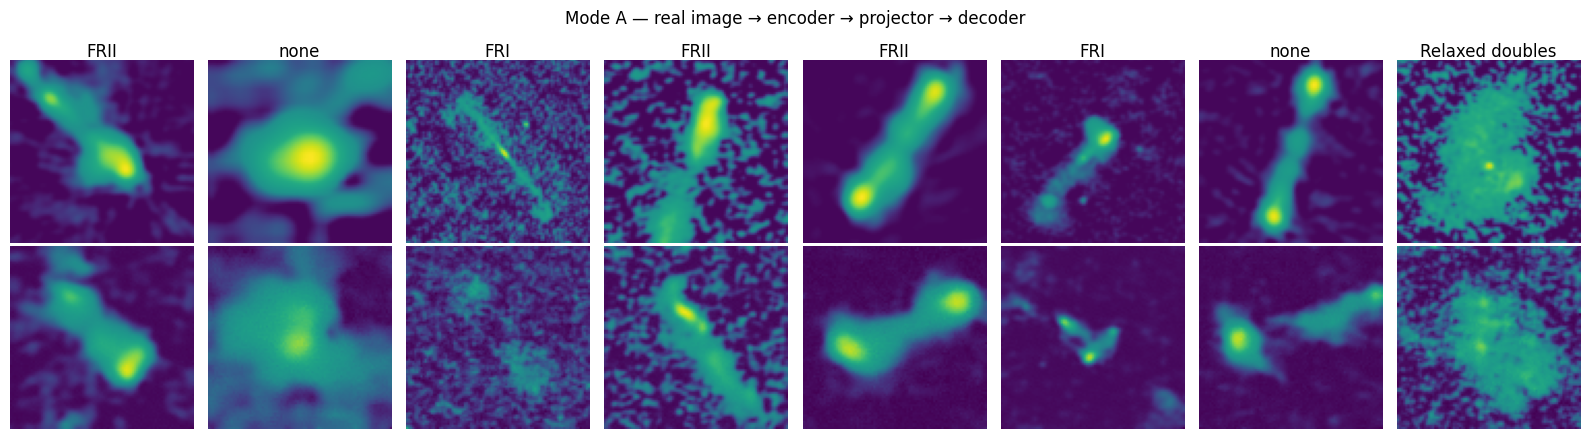

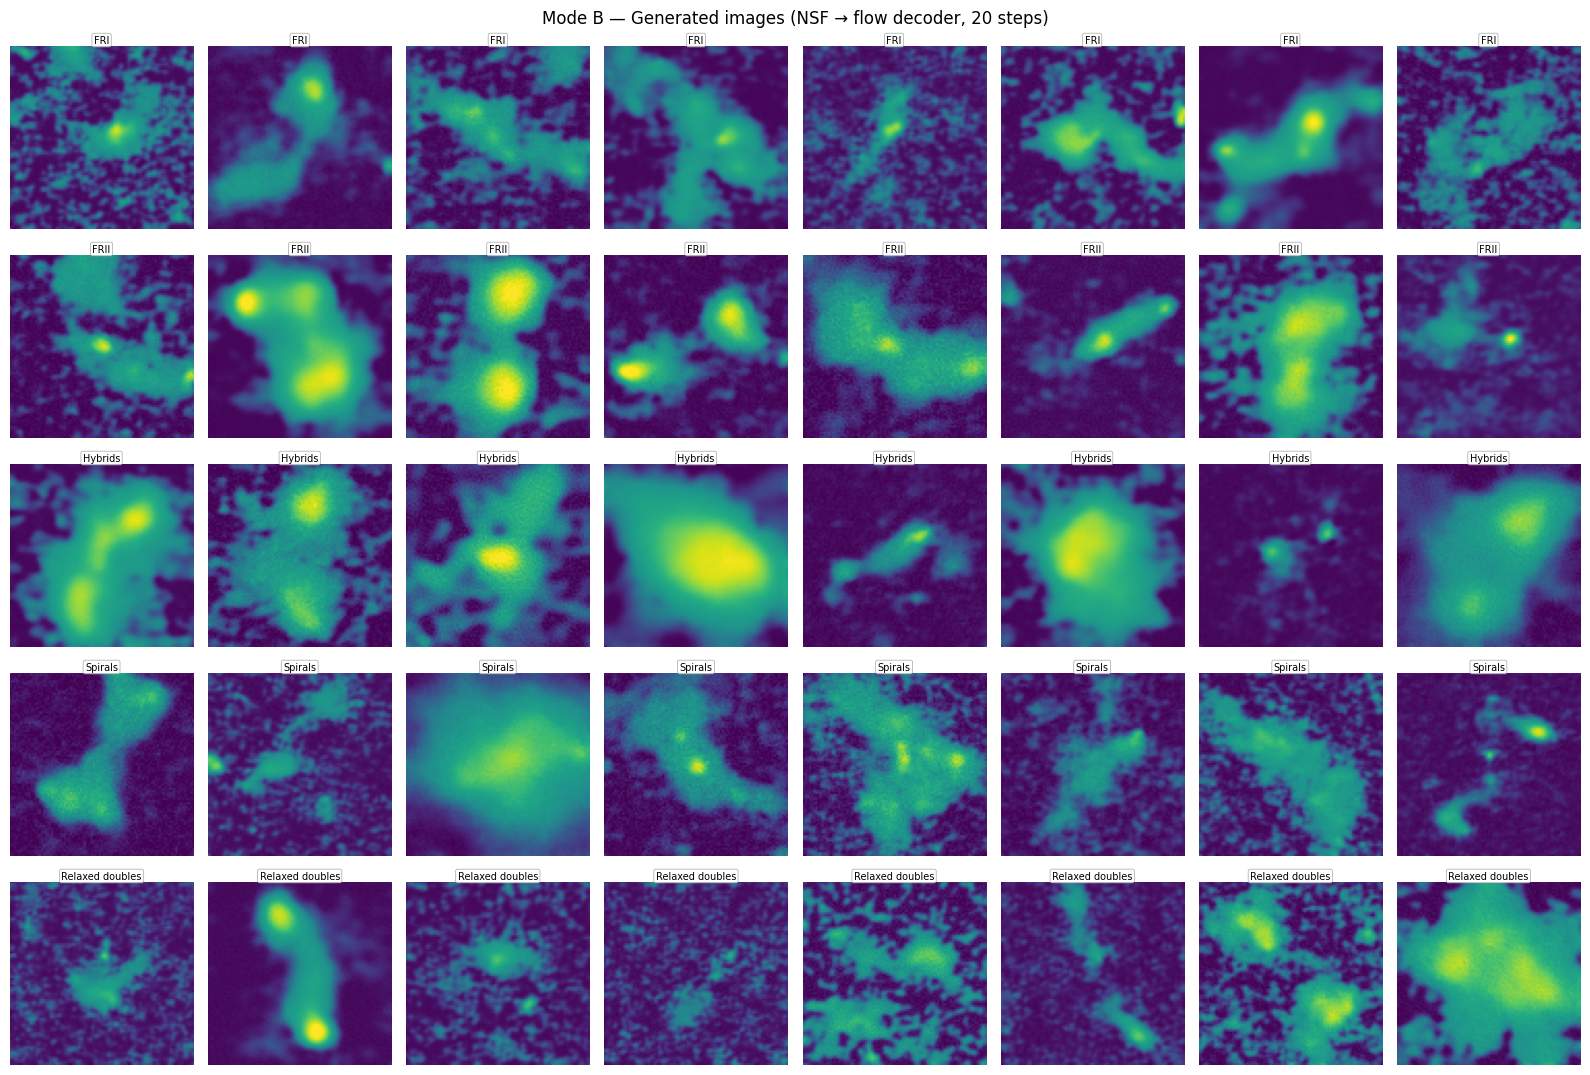

In [26]:
decoder.eval()
flow.eval()

FLOW_N_STEPS  = CONFIG.get("flow_n_steps", 20)
USE_PROJ      = CONFIG.get("use_projections", True)

# ─── Mode A: Reconstruct real images via encoder ──────────────────────────────
# Encode a real image → project (if use_projections) → decode → compare
n_recon = 8
sample_imgs = val_imgs[:n_recon].to(device)

with torch.no_grad():
    enc_out = byol.online_encoder(sample_imgs)
    if USE_PROJ:
        z_enc = byol.online_projector(enc_out)   # same space as decoder training
    else:
        z_enc = enc_out
    recon = decoder.sample(z_enc, n_steps=FLOW_N_STEPS).cpu()

def _label_str(label_row):
    """Return a comma-separated string of active class names, or 'none'."""
    active = [label_names_subset[j] for j, v in enumerate(label_row) if v > 0.5]
    return ", ".join(active) if active else "none"

fig, axes = plt.subplots(2, n_recon, figsize=(2 * n_recon, 4.5))
for i in range(n_recon):
    axes[0, i].imshow(sample_imgs[i, 0].cpu().numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title(_label_str(val_y[i]), fontsize=12, pad=3)
    axes[1, i].imshow(recon[i, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Decoded", fontsize=10)
plt.suptitle(f"Mode A — real image → encoder {'→ projector' if USE_PROJ else ''} → decoder")
plt.tight_layout()
plt.show()

# ─── Mode B: Generate from flow samples ──────────────────────────────────────
# Label y → NSF sample z → decode → image
def generate_images(label_vector, n_samples=8):
    flow.eval(); decoder.eval()
    y = torch.tensor(label_vector, dtype=torch.float32, device=device)
    y = y.unsqueeze(0).expand(n_samples, -1)
    with torch.no_grad():
        z = flow(y).sample()
        return decoder.sample(z, n_steps=FLOW_N_STEPS).cpu()

n_gen_per_class = 8
fig, axes = plt.subplots(n_labels, n_gen_per_class, figsize=(2 * n_gen_per_class, 2.2 * n_labels))
if n_labels == 1:
    axes = axes[None, :]

for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    imgs_gen = generate_images(label_vec, n_samples=n_gen_per_class)
    for col in range(n_gen_per_class):
        ax = axes[row, col]
        ax.imshow(imgs_gen[col, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(name, fontsize=7, pad=2,
                     bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                               edgecolor="grey", alpha=0.7, linewidth=0.5))
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=55, va="center")

plt.suptitle(f"Mode B — Generated images (NSF → flow decoder, {FLOW_N_STEPS} steps)", fontsize=12)
plt.tight_layout()
plt.show()

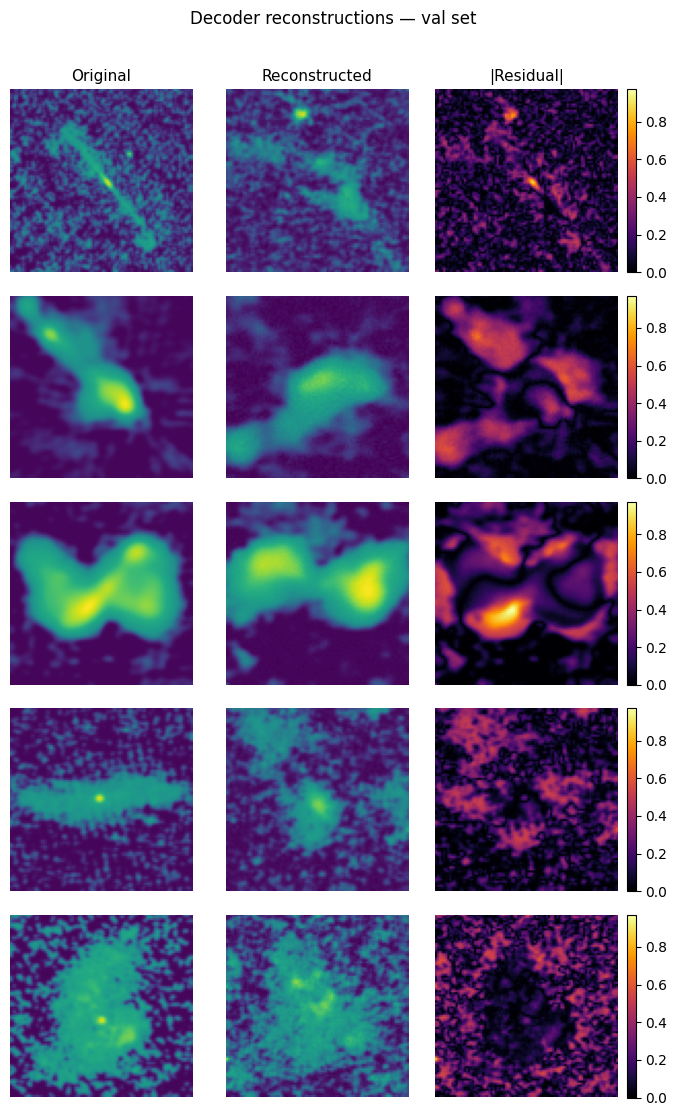

In [27]:
# 5 rows — one example per class (from val set)
# Columns: Original | Reconstructed | Residual

N_ROWS = 5

sample_indices = []
for c in range(min(N_ROWS, n_labels)):
    pos = np.where(val_y[:, c] > 0.5)[0]
    sample_indices.append(int(pos[0]) if len(pos) > 0 else c)

decoder.eval()
with torch.no_grad():
    z_sel = val_feats[sample_indices].to(device)
    recon = decoder.sample(z_sel, n_steps=FLOW_N_STEPS)   # already clamped [0,1]
orig     = val_imgs[sample_indices]
residual = (orig - recon.cpu()).abs()

fig, axes = plt.subplots(N_ROWS, 3, figsize=(7, 2.2 * N_ROWS))
col_titles = ["Original", "Reconstructed", "|Residual|"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, pad=6)

for row in range(N_ROWS):
    active    = [label_names_subset[c] for c in range(n_labels) if val_y[sample_indices[row], c] > 0.5]
    row_label = ", ".join(active) if active else "none"
    images    = [orig[row, 0].numpy(), recon.cpu()[row, 0].numpy(), residual[row, 0].numpy()]
    for col, img in enumerate(images):
        ax   = axes[row, col]
        vmax = 1.0 if col < 2 else residual.max().item()
        cmap = "viridis" if col < 2 else "inferno"
        im   = ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax)
        ax.axis("off")
        if col == 2:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[row, 0].set_ylabel(row_label, fontsize=9, rotation=0, labelpad=90, va="center", ha="right")

plt.suptitle("Decoder reconstructions — val set", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


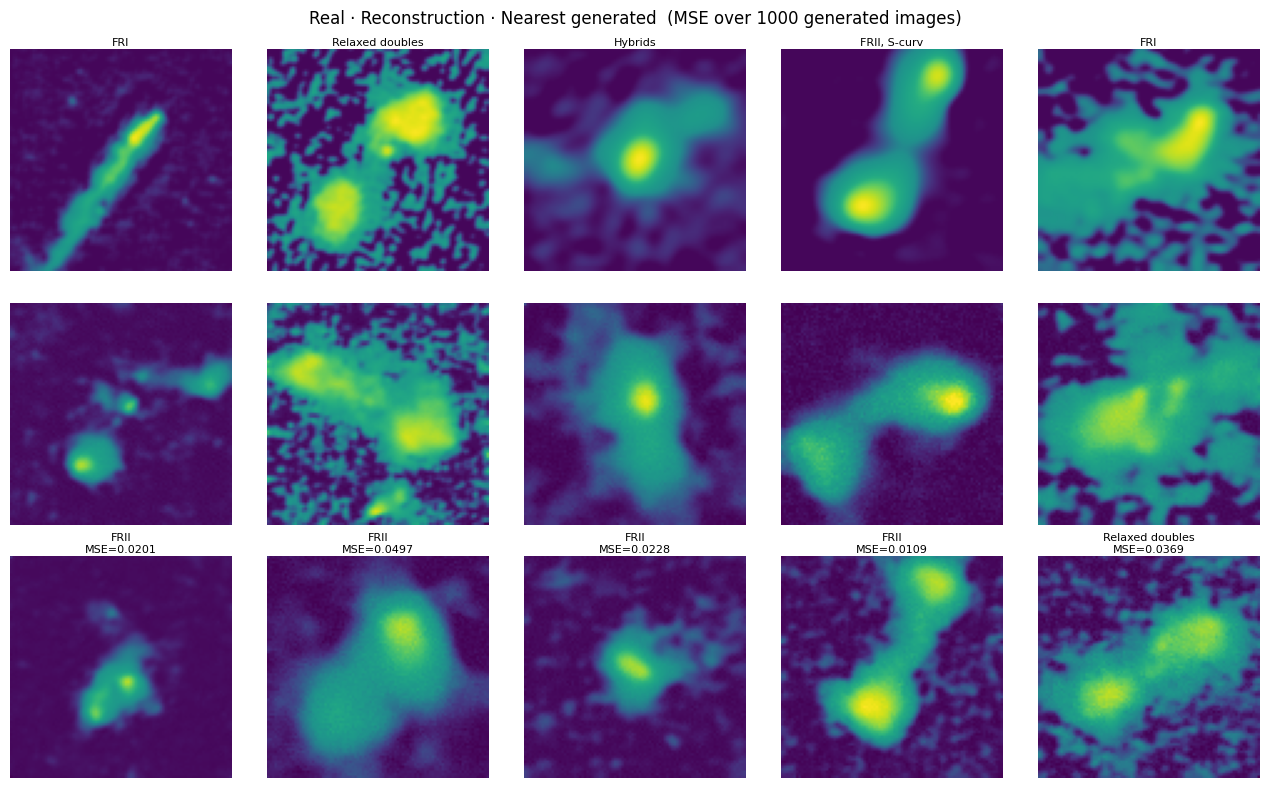

Saved → /users/mbredber/p3_SUPLAT/notebooks/outputs/nearest_generated_comparison.png


In [28]:
# ── Nearest-generated image comparison ───────────────────────────────────────
# For 5 randomly selected real images, shows:
#   Row 1 — original
#   Row 2 — reconstruction (encoder → decoder)
#   Row 3 — most similar generated image by MSE across N_GEN_SEARCH examples
# Label information is shown above each column / image.



N_COLS       = 5     # number of real images to sample
N_GEN_SEARCH = 1000  # generated images to search for nearest neighbour
SEED         = 0

ROOT    = Path("..").resolve()
OUT_DIR = ROOT / "notebooks" / "outputs"


# ── Load data ─────────────────────────────────────────────────────────────────
recon_cache   = OUT_DIR / "gen_reconstructed.npy"
gen_cache     = OUT_DIR / "gen_generated.npy"
gen_lbl_cache = OUT_DIR / "gen_labels.npy"
assert recon_cache.exists() and gen_cache.exists(), (
    "Image caches not found. Run Cell A first."
)
if all_images.max() > 1.5:
    all_images = all_images.astype(np.float32) / 255.0

recon_imgs_all = np.load(recon_cache)            # aligned with all_images
gen_imgs_all   = np.load(gen_cache)              # (N_gen, H, W)
gen_lbls_all   = (np.load(gen_lbl_cache)
                  if gen_lbl_cache.exists() else None)

# Label names for generated images — use session var if available, else indices
_gen_label_names = (label_names_subset
                    if 'label_names_subset' in dir()
                    else [str(i) for i in range(gen_lbls_all.shape[1]
                                                if gen_lbls_all is not None else 0)])

def _fmt_labels(label_row, names):
    active = [names[j] for j, v in enumerate(label_row) if v > 0.5]
    return ", ".join(active) if active else "—"

# ── Sample real images ────────────────────────────────────────────────────────
n_real = min(len(all_images), len(recon_imgs_all))
rng    = np.random.default_rng(SEED)
idxs   = rng.choice(n_real, size=N_COLS, replace=False)

# ── Find nearest generated image per real image (by MSE) ─────────────────────
search_imgs = gen_imgs_all[:N_GEN_SEARCH]         # (N_GEN_SEARCH, H, W)
nearest_imgs, nearest_mse, nearest_lbls = [], [], []
for idx in idxs:
    diff = search_imgs - all_images[idx]       # broadcast (N, H, W)
    mse  = (diff ** 2).mean(axis=(1, 2))
    best = int(mse.argmin())
    nearest_imgs.append(search_imgs[best])
    nearest_mse.append(float(mse[best]))
    nearest_lbls.append(gen_lbls_all[best] if gen_lbls_all is not None else None)

# ── Plot ──────────────────────────────────────────────────────────────────────
row_labels = ["Original", "Reconstruction", "Nearest\ngenerated"]
fig, axes  = plt.subplots(3, N_COLS, figsize=(2.6 * N_COLS, 8))

for col, idx in enumerate(idxs):
    real_lbl_str    = _fmt_labels(all_labels[idx], ALL_CLASS_NAMES)
    nearest_lbl_str = (_fmt_labels(nearest_lbls[col], _gen_label_names)
                       if nearest_lbls[col] is not None else "—")

    # Row 0 — original (label title shown)
    axes[0, col].imshow(all_images[idx], cmap="viridis", vmin=0, vmax=1)
    axes[0, col].set_title(real_lbl_str, fontsize=8, pad=3)

    # Row 1 — reconstruction (no title)
    axes[1, col].imshow(recon_imgs_all[idx], cmap="viridis", vmin=0, vmax=1)

    # Row 2 — nearest generated (label + MSE shown)
    axes[2, col].imshow(nearest_imgs[col], cmap="viridis", vmin=0, vmax=1)
    axes[2, col].set_title(
        f"{nearest_lbl_str}\nMSE={nearest_mse[col]:.4f}", fontsize=8, pad=3
    )

# Turn off axis decorations; restore ylabel on leftmost cell of each row
for row in range(3):
    for col in range(N_COLS):
        axes[row, col].axis("off")
    # Re-enable ylabel after axis("off")
    axes[row, 0].set_ylabel(row_labels[row], fontsize=11, va="center", labelpad=6)
    axes[row, 0].yaxis.label.set_visible(True)

plt.suptitle(
    f"Real · Reconstruction · Nearest generated  "
    f"(MSE over {N_GEN_SEARCH} generated images)",
    fontsize=12,
)
plt.tight_layout()
out_path = OUT_DIR / "nearest_generated_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

### Pixel Intensity Histogram Comparison

Compares the pixel intensity distribution of real, reconstructed, and generated images.
A good generative model should produce images whose intensity statistics match the real data.

**Settings** (edit at the top of the cell below):

| Setting | Options | Default |
|---------|---------|---------|
| `CLASS_SUBSET` | `"full"` \| class name \| list of names/ints | `"full"` |
| `PIXEL_MODE` | `"all"` \| `"brightest"` \| `"sum"` | `"all"` |

**`CLASS_SUBSET`** filters which images are included:
- `"full"` — all images
- A class name string, e.g. `"FRI"`, `"FRII"`, `"Hybrids"`
- A list, e.g. `["FRI", "FRII"]` — keeps images where *any* listed class is set

**`PIXEL_MODE`** controls what counts as one histogram sample:
- `"all"` — every pixel independently (n_images × 89 × 89 values)
- `"brightest"` — the single maximum pixel per image (n_images values)
- `"sum"` — the total pixel intensity sum per image (n_images values)

**RMAE** (Relative Mean Absolute Error) is shown in the legend for each generated set:
`RMAE = mean(|hist_real − hist_gen|) / mean(hist_real)`

Reconstructed/generated image arrays are cached in `notebooks/outputs/` after the
first run so this cell can be re-run independently.

In [29]:
# ── Pixel Histogram: COMPUTATION (Cell A) ────────────────────────────────────
# Generates image caches if missing, then computes histograms and saves a
# .npz cache for Cell B (plotting). Re-run when CLASS_SUBSET, PIXEL_MODE, or
# the model changes. Set FORCE_RECOMPUTE=True to regenerate image caches.

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
CLASS_SUBSET     = "FRI"   # "full" | class name string | list of names/ints
PIXEL_MODE       = "sum"    # "all" | "brightest" | "sum"
FORCE_RECOMPUTE  = False    # True → regenerate image caches even if they exist
N_COMPUTE        = 1000     # max images to reconstruct / generate
# ─────────────────────────────────────────────────────────────────────────────

ROOT    = Path("..").resolve()
OUT_DIR = ROOT / "notebooks" / "outputs"
OUT_DIR.mkdir(exist_ok=True)

N_BINS = 30
EPS    = 1e-10


def _resolve_class_indices(subset):
    if subset == "full":
        return None
    items = subset if isinstance(subset, list) else [subset]
    indices = []
    for item in items:
        if isinstance(item, int):
            indices.append(item)
        else:
            if item not in ALL_CLASS_NAMES:
                raise ValueError(f"Unknown class name: {item!r}. "
                                 f"Choose from: {ALL_CLASS_NAMES}")
            indices.append(ALL_CLASS_NAMES.index(item))
    return indices

def _class_mask(labels_2d, col_indices):
    return labels_2d[:, col_indices].any(axis=1)

def _extract_pixels(imgs, mode):
    flat = imgs.reshape(len(imgs), -1)
    if mode == "all":         return flat.ravel()
    elif mode == "brightest": return flat.max(axis=1)
    elif mode == "sum":       return flat.sum(axis=1)
    else: raise ValueError(f"Unknown PIXEL_MODE: {mode!r}.")

# ── 1. Real images ────────────────────────────────────────────────────────────
class_indices = _resolve_class_indices(CLASS_SUBSET)
class_label   = (CLASS_SUBSET if isinstance(CLASS_SUBSET, str)
                 else "+".join(str(c) for c in CLASS_SUBSET)) if CLASS_SUBSET != "full" else "full"

if class_indices is not None:
    real_mask = _class_mask(all_labels, class_indices)
    real_imgs = all_images[real_mask]
    print(f"Class filter: {class_label}  ({real_mask.sum()} / {len(all_images)} kept)")
else:
    real_mask = None
    real_imgs = all_images

# Normalise to [0, 1] float32 for histogram and BYOL input
if real_imgs.max() > 1.5:
    real_imgs = real_imgs.astype(np.float32) / 255.0

# ── 2. Generate image caches (if needed) ──────────────────────────────────────
recon_cache   = OUT_DIR / "gen_reconstructed.npy"
gen_cache     = OUT_DIR / "gen_generated.npy"
gen_lbl_cache = OUT_DIR / "gen_labels.npy"

if not FORCE_RECOMPUTE and recon_cache.exists() and gen_cache.exists():
    print("Image caches found — skipping generation.")
else:
    assert 'decoder' in dir() and 'byol' in dir() and 'flow' in dir(), (
        "Model variables not found. Run earlier cells first, "
        "or ensure cached .npy files exist in notebooks/outputs/."
    )
    _device   = next(decoder.parameters()).device
    _dec_type = CONFIG.get("decoder_type", "flow")
    _steps    = CONFIG.get("flow_n_steps", 20)
    _use_proj = CONFIG.get("use_projections", True)
    _batch    = 64

    def _dec(z):
        return decoder.sample(z, n_steps=_steps) if _dec_type == "flow" else decoder(z)

    n_compute = min(len(all_images), N_COMPUTE)

    # Mode A: reconstruct real images
    byol.eval(); decoder.eval()
    recon_list = []
    with torch.no_grad():
        for i in tqdm(range(0, n_compute, _batch), desc="Reconstructing"):
            _raw = all_images[i:i + _batch].astype(np.float32)
            if _raw.max() > 1.5:
                _raw /= 255.0
            x   = torch.from_numpy(_raw[:, None]).to(_device)
            enc = byol.online_encoder(x)
            z   = byol.online_projector(enc) if _use_proj else enc
            recon_list.append(_dec(z).cpu().numpy()[:, 0])
    recon_imgs_all = np.concatenate(recon_list)
    np.save(recon_cache, recon_imgs_all)
    print(f"Saved → {recon_cache}  ({len(recon_imgs_all)} images)")

    # Mode B: generate from NSF conditioned on val labels
    _labels = val_y[:n_compute]
    flow.eval(); decoder.eval()
    gen_list, gen_lbl_list = [], []
    import time as _time
    _t0 = _time.perf_counter()
    with torch.no_grad():
        for i in tqdm(range(0, len(_labels), _batch), desc="Generating  "):
            y_batch = torch.from_numpy(_labels[i:i + _batch]).to(_device)
            z       = flow(y_batch).sample()
            gen_list.append(_dec(z).cpu().numpy()[:, 0])
            gen_lbl_list.append(_labels[i:i + _batch])
    _t1 = _time.perf_counter()
    print(f"  Generated {len(_labels)} images in {_t1-_t0:.1f} s  "
          f"({((_t1-_t0)/len(_labels))*1000:.1f} ms/image)")
    gen_imgs_all = np.concatenate(gen_list)
    gen_lbls_all = np.concatenate(gen_lbl_list)
    np.save(gen_cache,     gen_imgs_all)
    np.save(gen_lbl_cache, gen_lbls_all)
    print(f"Saved → {gen_cache}  ({len(gen_imgs_all)} images)")

# ── 3. Load image caches ──────────────────────────────────────────────────────
recon_imgs_all = np.load(recon_cache)
gen_imgs_all   = np.load(gen_cache)
gen_lbls_all   = np.load(gen_lbl_cache) if gen_lbl_cache.exists() else None
print(f"Real:          {len(real_imgs):6d}  |  "
      f"Reconstructed: {len(recon_imgs_all):6d}  |  "
      f"Generated: {len(gen_imgs_all):6d}")

if class_indices is not None:
    recon_imgs = recon_imgs_all[real_mask[:len(recon_imgs_all)]]
else:
    recon_imgs = recon_imgs_all

if class_indices is not None and gen_lbls_all is not None:
    gen_mask = _class_mask(gen_lbls_all.astype(int), class_indices)
    gen_imgs = gen_imgs_all[gen_mask]
    print(f"After class filter: recon={len(recon_imgs)}, gen={len(gen_imgs)}")
else:
    gen_imgs = gen_imgs_all

# ── 4. Extract pixels ─────────────────────────────────────────────────────────
n_use    = min(len(real_imgs), len(recon_imgs), len(gen_imgs))
px_real  = _extract_pixels(real_imgs[:n_use],  PIXEL_MODE)
px_recon = _extract_pixels(recon_imgs[:n_use], PIXEL_MODE)
px_gen   = _extract_pixels(gen_imgs[:n_use],   PIXEL_MODE)
mode_label = {"all": "pixels", "brightest": "images (brightest pixel)",
              "sum": "images (pixel sum)"}[PIXEL_MODE]
print(f"Using {n_use:,} images → {len(px_real):,} {mode_label} per set")

# ── 5. Histogram bins ─────────────────────────────────────────────────────────
if PIXEL_MODE == "sum":
    hi   = float(np.percentile(px_real, 99)) * 1.05
    BINS = np.linspace(0, hi, N_BINS + 1)
else:
    BINS = np.linspace(0, 1, N_BINS + 1)

hist_real,  _ = np.histogram(px_real,  bins=BINS, density=True)
hist_recon, _ = np.histogram(px_recon, bins=BINS, density=True)
hist_gen,   _ = np.histogram(px_gen,   bins=BINS, density=True)

# ── 6. Metrics ────────────────────────────────────────────────────────────────
def rmae(h_ref, h_cmp):
    return np.mean(np.abs(h_ref - h_cmp)) / (np.mean(h_ref) + EPS)

rmae_recon  = rmae(hist_real, hist_recon)
rmae_gen    = rmae(hist_real, hist_gen)
resid_recon = 2 * (hist_real - hist_recon) / (hist_real + hist_recon + EPS)
resid_gen   = 2 * (hist_real - hist_gen)   / (hist_real + hist_gen   + EPS)
print(f"RMAE  recon={rmae_recon:.4f}  gen={rmae_gen:.4f}")

# ── 7. Save histogram cache ───────────────────────────────────────────────────
hist_cache = OUT_DIR / f"pixel_hist_cache_{class_label}_{PIXEL_MODE}.npz"
np.savez(
    hist_cache,
    BINS        = BINS,
    hist_real   = hist_real,
    hist_recon  = hist_recon,
    hist_gen    = hist_gen,
    resid_recon = resid_recon,
    resid_gen   = resid_gen,
    rmae_recon  = np.array(rmae_recon),
    rmae_gen    = np.array(rmae_gen),
    n_use       = np.array(n_use),
    n_px        = np.array(len(px_real)),
)
print(f"Histogram cache saved → {hist_cache}")

Class filter: FRI  (2403 / 7596 kept)
Image caches found — skipping generation.
Real:            2403  |  Reconstructed:   1024  |  Generated:   1000
After class filter: recon=296, gen=316
Using 296 images → 296 images (pixel sum) per set
RMAE  recon=0.2271  gen=0.2245
Histogram cache saved → /users/mbredber/p3_SUPLAT/notebooks/outputs/pixel_hist_cache_FRI_sum.npz


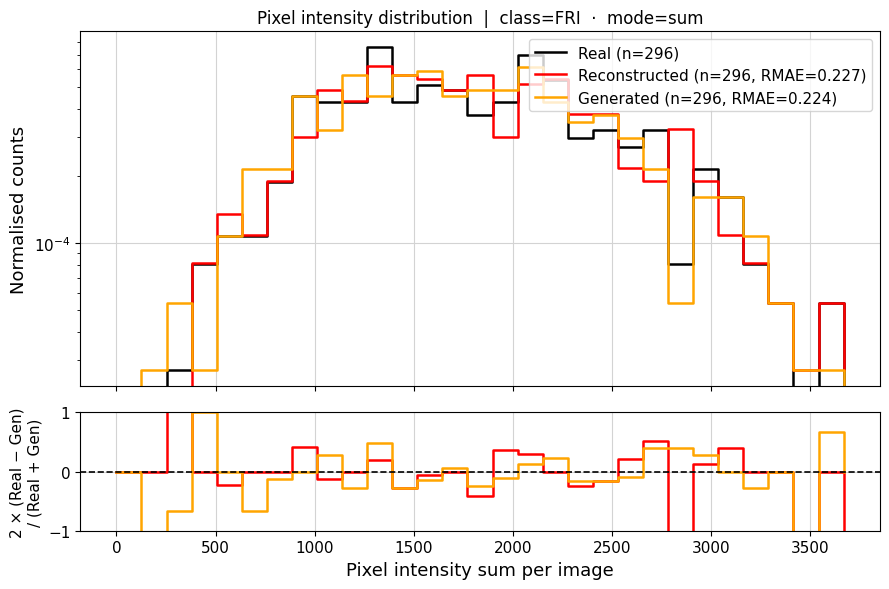

Saved → /users/mbredber/p3_SUPLAT/notebooks/outputs/pixel_histogram_comparison_FRI_sum.png


In [30]:
# ── Pixel Histogram: PLOTTING (Cell B) ───────────────────────────────────────
# Loads histogram cache saved by Cell A — runs instantly.
# CLASS_SUBSET and PIXEL_MODE must match what was used in Cell A.

# ── Must match Cell A settings ────────────────────────────────────────────────
CLASS_SUBSET = "FRI" # "full" | class name string | list of names/ints
PIXEL_MODE   = "sum" # "all" | "brightest" | "sum"
# ─────────────────────────────────────────────────────────────────────────────

ROOT    = Path("..").resolve()
OUT_DIR = ROOT / "notebooks" / "outputs"

class_label = (CLASS_SUBSET if isinstance(CLASS_SUBSET, str)
               else "+".join(str(c) for c in CLASS_SUBSET)) if CLASS_SUBSET != "full" else "full"

hist_cache = OUT_DIR / f"pixel_hist_cache_{class_label}_{PIXEL_MODE}.npz"
assert hist_cache.exists(), (
    f"Cache not found: {hist_cache}\nRun Cell A first with matching CLASS_SUBSET / PIXEL_MODE."
)

d           = np.load(hist_cache)
BINS        = d["BINS"]
hist_real   = d["hist_real"]
hist_recon  = d["hist_recon"]
hist_gen    = d["hist_gen"]
resid_recon = d["resid_recon"]
resid_gen   = d["resid_gen"]
rmae_recon  = d["rmae_recon"].item()
rmae_gen    = d["rmae_gen"].item()
n_px        = d["n_px"].item()

x_labels = {
    "all":       "Intensity for each pixel",
    "brightest": "Brightest pixel intensity per image",
    "sum":       "Pixel intensity sum per image",
}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax_top.step(BINS[:-1], hist_real,  where="post", color="black",  linewidth=1.8,
            label=f"Real (n={n_px:,})")
ax_top.step(BINS[:-1], hist_recon, where="post", color="red",    linewidth=1.8,
            label=f"Reconstructed (n={n_px:,}, RMAE={rmae_recon:.3f})")
ax_top.step(BINS[:-1], hist_gen,   where="post", color="orange", linewidth=1.8,
            label=f"Generated (n={n_px:,}, RMAE={rmae_gen:.3f})")

ax_top.set_yscale("log")
ax_top.set_ylabel("Normalised counts", fontsize=13)
ax_top.legend(loc="upper right", fontsize=11)
ax_top.grid(True, color="lightgrey", linewidth=0.8)
ax_top.set_title(
    f"Pixel intensity distribution  |  class={class_label}  ·  mode={PIXEL_MODE}",
    fontsize=12,
)
ax_top.tick_params(labelsize=11)

ax_bot.step(BINS[:-1], resid_recon, where="post", color="red",    linewidth=1.8)
ax_bot.step(BINS[:-1], resid_gen,   where="post", color="orange", linewidth=1.8)
ax_bot.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax_bot.set_ylim(-1, 1)
ax_bot.set_ylabel("2 × (Real − Gen)\n/ (Real + Gen)", fontsize=11)
ax_bot.set_xlabel(x_labels[PIXEL_MODE], fontsize=13)
ax_bot.grid(True, color="lightgrey", linewidth=0.8)
ax_bot.tick_params(labelsize=11)

plt.tight_layout()

suffix   = f"_{class_label}_{PIXEL_MODE}" if CLASS_SUBSET != "full" or PIXEL_MODE != "all" else ""
out_path = OUT_DIR / f"pixel_histogram_comparison{suffix}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## 10. Projection Space Visualisations

### 10a. UMAP

Projects real training projections and NSF-generated projections into 2-D with UMAP.
Real projections are shown as circles; generated samples as stars (★).
A well-trained flow should place generated points inside the same clusters as real ones.

### 10b. Generated ↔ Real KNN Gallery

For each selected class, samples a generated image (shown centre, yellow border) and
finds its 8 nearest real-image neighbours in the BYOL embedding space using KNN.
Reveals whether generated images occupy the same embedding regions as real data.

### 10c. Class interpolation

Linearly interpolates between two class-conditioned NSF samples in projection space
and decodes each step.  This reveals whether the decoder produces smooth, meaningful
transitions across classes.

Fitting UMAP on train projections…


/users/mbredber/.venv/lib64/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


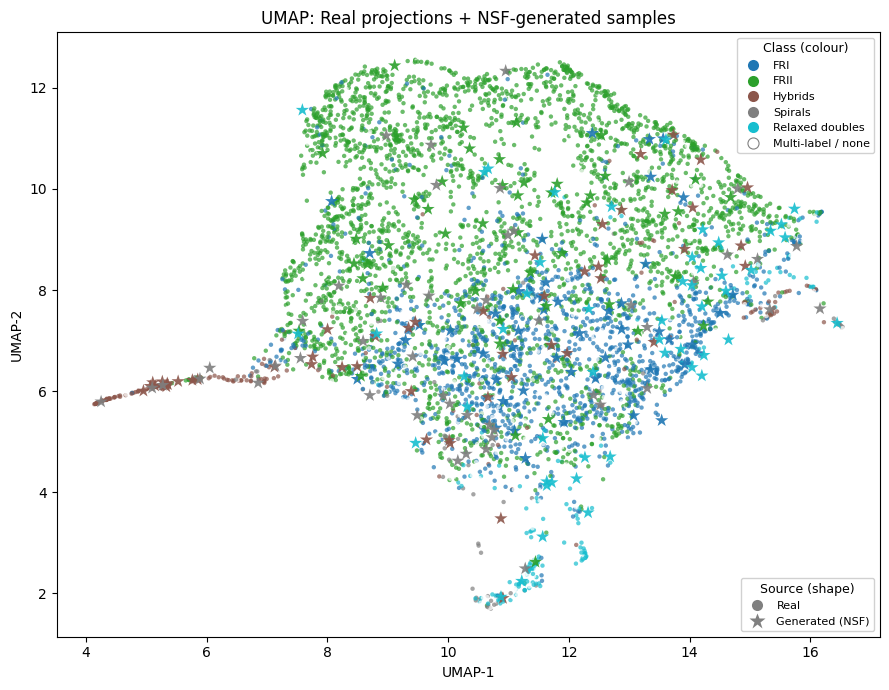

In [31]:
feat_label = "projections" if USE_PROJECTIONS else "encoder features"
print(f"Fitting UMAP on train {feat_label}…")
reducer    = umap.UMAP(random_state=CONFIG["seed"], n_neighbors=15, min_dist=0.1)
umap_train = reducer.fit_transform(train_feats.numpy())   # (N_train, 2)

# Generate samples from the NSF for each class
n_gen_umap = max(50, 200 // n_labels)
flow.eval()
gen_zs, gen_class_ids = [], []
for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    y = torch.tensor([label_vec], dtype=torch.float32, device=device).expand(n_gen_umap, -1)
    with torch.no_grad():
        z_gen = flow(y).sample().cpu().numpy()
    gen_zs.append(z_gen)
    gen_class_ids.extend([row] * n_gen_umap)

gen_zs_all    = np.concatenate(gen_zs, axis=0)
umap_gen      = reducer.transform(gen_zs_all)
gen_class_ids = np.array(gen_class_ids)

# ── Colour palette ────────────────────────────────────────────────────────────
cmap_cls     = plt.colormaps.get_cmap("tab10").resampled(n_labels)
class_colors = [cmap_cls(i) for i in range(n_labels)]

# ── Assign colours to real points ─────────────────────────────────────────────
real_colors = []
for i in range(len(train_y)):
    active = np.where(train_y[i] > 0.5)[0]
    real_colors.append(class_colors[active[0]] if len(active) == 1 else (1.0, 1.0, 1.0, 1.0))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(umap_train[:, 0], umap_train[:, 1],
           c=real_colors, s=10, alpha=0.7, edgecolors="none", marker="o", zorder=2)
for i, name in enumerate(label_names_subset):
    mask = gen_class_ids == i
    ax.scatter(umap_gen[mask, 0], umap_gen[mask, 1],
               color=class_colors[i], marker="*", s=100, alpha=0.9, edgecolors="none", zorder=3)

class_handles = [
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor=class_colors[i], markeredgecolor="none",
           markersize=8, label=label_names_subset[i])
    for i in range(n_labels)
]
class_handles.append(
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.8,
           markersize=8, label="Multi-label / none")
)
leg1 = ax.legend(handles=class_handles, title="Class (colour)",
                 loc="upper right", fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=[
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=8, label="Real"),
    Line2D([0], [0], marker="*", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=12, label="Generated (NSF)"),
], title="Source (shape)", loc="lower right", fontsize=8, title_fontsize=9, framealpha=0.9)

ax.set_title(f"UMAP: Real {feat_label} + NSF-generated samples")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

Encoding generated images…
  gen_projs: (1000, 192)  |  real_projs: (1139, 192)
Run: run_cnxt_pca_pond_step_wd_20260507_1151  |  split: val


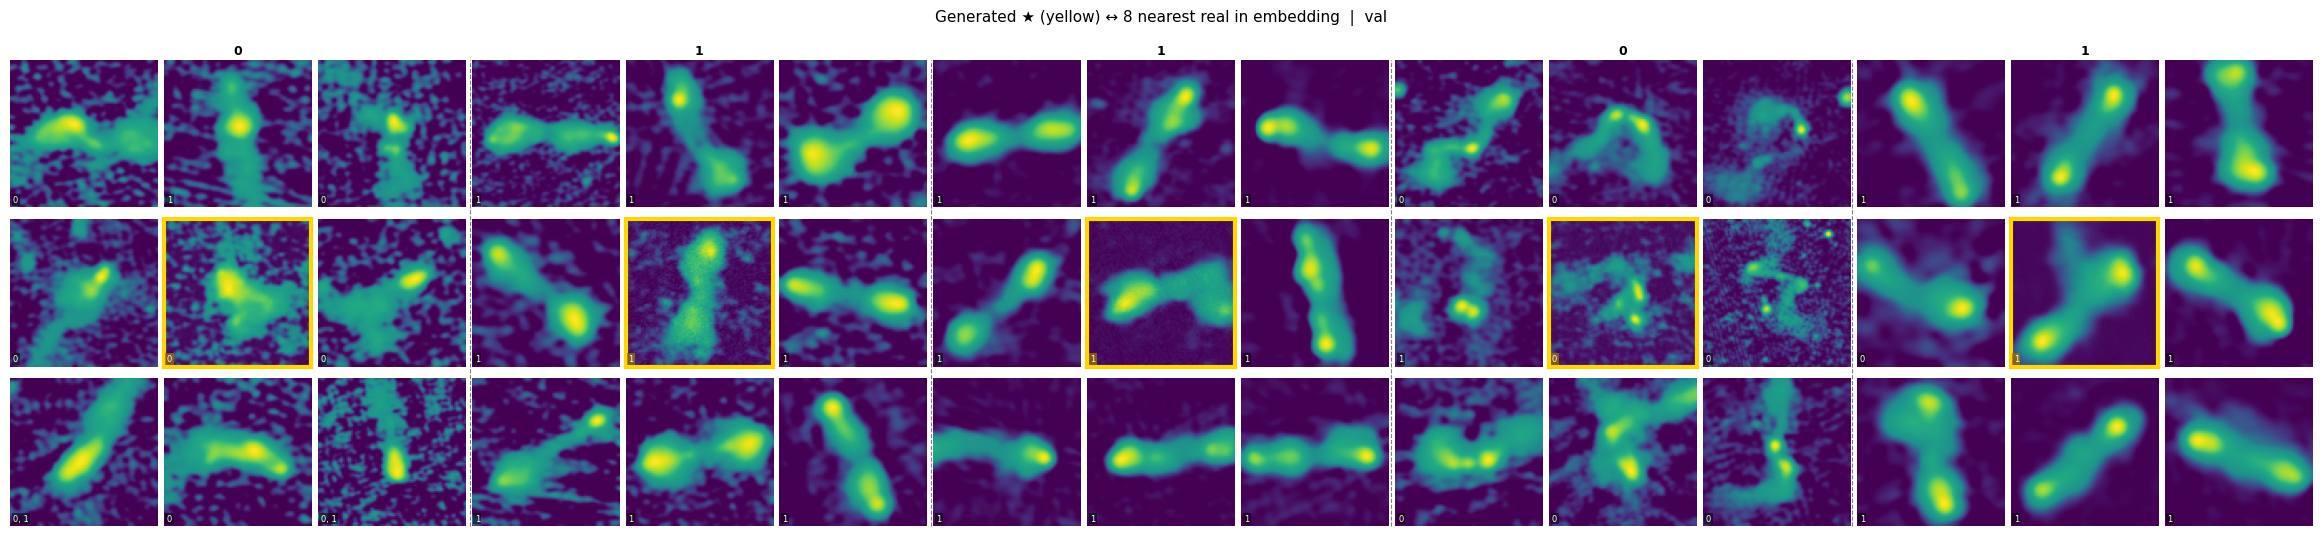

In [32]:
# =============================================================================
# Generated ↔ Real KNN Gallery
# Centre cell (yellow border) = a generated image.
# Surrounding 8 cells = nearest real images in BYOL embedding space.
# =============================================================================
split           = 'val'   # real split to search against
N               = 5       # number of generated images to show
seed            = 42
GEN_CACHE       = Path('..') / 'notebooks' / 'outputs'
# Label names for generated images (must match the label_subset used in
# generative_modelling.ipynb).  Set to None to fall back to indices.
GEN_LABEL_NAMES = None    # e.g. ['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles']
# =============================================================================

import sys
import torch
from sklearn.neighbors import NearestNeighbors
sys.path.insert(0, str(Path('..') / 'src'))
from suplat.models.byol_models import (
    BYOLEfficient, BYOLEfficientNetB0, BYOLPretrainedBackbone,
    create_resnet18_backbone, create_resnet50_backbone,
    create_convnext_tiny_backbone, PCAProjection,
)


# ── Load generated images & labels ───────────────────────────────────────────
assert (GEN_CACHE / 'gen_generated.npy').exists(), \
    "Run Cell A in generative_modelling.ipynb first to create the image caches."
gen_imgs = np.load(GEN_CACHE / 'gen_generated.npy').astype(np.float32)
gen_lbls = np.load(GEN_CACHE / 'gen_labels.npy') if (GEN_CACHE / 'gen_labels.npy').exists() else None
if gen_imgs.max() > 1.5:
    gen_imgs /= 255.0

n_gen_labels  = gen_lbls.shape[1] if gen_lbls is not None else 0
gen_lbl_names = (GEN_LABEL_NAMES if GEN_LABEL_NAMES is not None
                 else ALL_CLASS_NAMES if n_gen_labels == 20
                 else [str(i) for i in range(n_gen_labels)])

# ── Real images, projections and labels from session (cells 6 & 8) ──────────
_n    = {'train': len(keep_train_mask), 'val': len(keep_val_mask), 'test': len(keep_test_mask)}
_idx  = {'train': train_idx, 'val': val_idx, 'test': test_idx}
_mask = {'train': keep_train_mask, 'val': keep_val_mask, 'test': keep_test_mask}
real_projs  = {'train': train_z, 'val': val_z, 'test': test_z}[split]
real_labels = {'train': train_lbl_full[keep_train_mask],
               'val':   val_lbl_full[keep_val_mask],
               'test':  test_lbl_full[keep_test_mask]}[split]
real_imgs   = all_images[_idx[split][:_n[split]]][_mask[split]]

# ── Encode generated images using session BYOL (loaded in cell 8) ──────────
device = next(byol.parameters()).device

def _encode(imgs, model, device, bs=128):
    out = []
    t = torch.from_numpy(imgs[:, None])
    with torch.no_grad():
        for i in range(0, len(t), bs):
            x = t[i:i+bs].to(device)
            out.append(model.online_projector(model.online_encoder(x)).cpu().numpy())
    return np.concatenate(out)

print('Encoding generated images…')
gen_projs = _encode(gen_imgs, byol, device)
print(f'  gen_projs: {gen_projs.shape}  |  real_projs: {real_projs.shape}')

# ── KNN: fit on real, query with generated ────────────────────────────────────
nn_model     = NearestNeighbors(n_neighbors=8, metric='euclidean').fit(real_projs)
rng          = np.random.default_rng(seed)
sel_idxs     = rng.choice(len(gen_projs), size=N, replace=False)
_, knn_indices = nn_model.kneighbors(gen_projs[sel_idxs])   # (N, 8)

# ── Plot ──────────────────────────────────────────────────────────────────────
def wrap_label(s, max_chars=18):
    parts = [p.strip() for p in s.split(',')]
    lines, cur = [], ''
    for p in parts:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

cell_size  = 1.6
left_mar, right_mar, top_mar, bottom_mar = 0.02, 0.02, 0.10, 0.02

fig, axes = plt.subplots(
    3, 3 * N,
    figsize=(cell_size * 3 * N, cell_size * 3 + 0.5),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08},
)
fig.subplots_adjust(left=left_mar, right=1-right_mar,
                    top=1-top_mar, bottom=bottom_mar)

for i, gi in enumerate(sel_idxs):
    nn_idxs    = knn_indices[i]
    col_offset = i * 3

    # 3×3 grid: centre = generated, rest = nearest real neighbours
    grid = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
            nn_idxs[3], None,        nn_idxs[4],
            nn_idxs[5], nn_idxs[6], nn_idxs[7]]

    gen_active = ([gen_lbl_names[j] for j, v in enumerate(gen_lbls[gi]) if v > 0.5]
                  if gen_lbls is not None else [])
    gen_tag    = ', '.join(gen_active) if gen_active else '—'
    axes[0, col_offset + 1].set_title(
        wrap_label(gen_tag, max_chars=22), fontsize=9, fontweight='bold', pad=4
    )

    for flat_pos, real_idx in enumerate(grid):
        row     = flat_pos // 3
        col_pos = col_offset + (flat_pos % 3)
        ax      = axes[row, col_pos]

        if real_idx is None:
            # Centre: generated image
            ax.imshow(gen_imgs[gi], cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.02, wrap_label(gen_tag), transform=ax.transAxes,
                    fontsize=6, color='white', va='bottom', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            ax.imshow(real_imgs[real_idx], cmap='viridis', origin='lower')
            ax.axis('off')
            lbl    = real_labels[real_idx]
            active = [gen_lbl_names[j] for j in range(len(lbl)) if lbl[j] == 1]
            ax.text(0.02, 0.02, wrap_label(', '.join(active) if active else '—'),
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='bottom', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

    if i < N - 1:
        plot_width = 1 - left_mar - right_mar
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N)
        fig.add_artist(plt.matplotlib.lines.Line2D(
            [x_sep, x_sep], [bottom_mar, 1 - top_mar],
            transform=fig.transFigure,
            color='grey', linewidth=0.8, linestyle='--', zorder=10,
        ))

run_name = Path(CONFIG["base_dir"]).name
print(f'Run: {run_name}  |  split: {split}')
fig.suptitle(f'Generated ★ (yellow) ↔ 8 nearest real in embedding  |  {split}',
             fontsize=11, y=0.995)
plt.show()

Uses **nDCG@k** (Normalized Discounted Cumulative Gain) to quantify whether
generated images embed in the correct class region of the BYOL projection space.

For each generated image with target class *c*:
1. Encode it through the session BYOL encoder → projector
2. Find its K nearest real images in embedding space (cosine distance, full val pool)
3. Measure how highly real images of class *c* rank among those K neighbours

**Gen → Real nDCG@k** answers: *"Do generated FRI images retrieve real FRI images?"*
Compared against **Real → Real nDCG@k** (leave-one-out baseline on the same split).

Score of 1.0 = all K nearest neighbours share the correct class; 0.0 = none do.

Reusing gen_projs from KNN Gallery cell.


nDCG@10:  40%|████      | 2/5 [00:00<00:00,  7.44it/s]

nDCG@10: 100%|██████████| 5/5 [00:00<00:00, 15.57it/s]


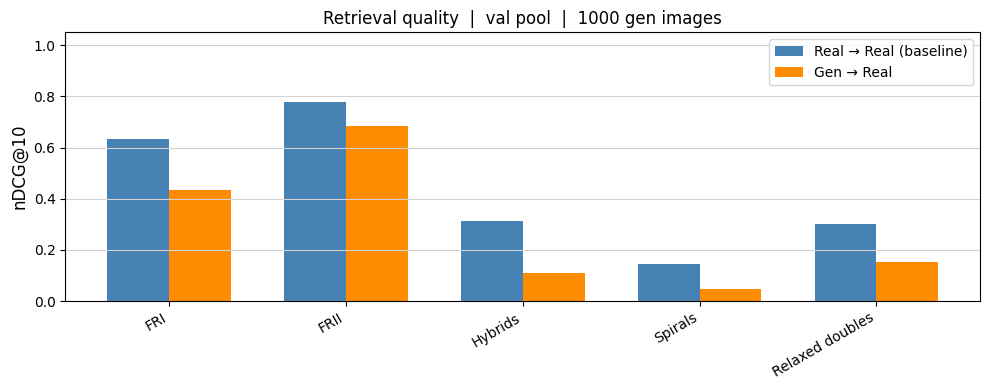

Saved → /users/mbredber/p3_SUPLAT/notebooks/outputs/ndcg_retrieval_quality.png

Class                   Real→Real   Gen→Real        Δ
----------------------------------------------------
FRI                         0.634      0.434   -0.199
FRII                        0.777      0.686   -0.091
Hybrids                     0.311      0.110   -0.201
Spirals                     0.144      0.046   -0.098
Relaxed doubles             0.299      0.154   -0.146


In [33]:
# ── Settings ────────────────────────────────────────────────────────────────
K         = 10     # retrieval cutoff
split     = 'val'  # real pool to query: 'train' | 'val' | 'test'
N_GEN_USE = 1000   # cap on generated images to evaluate

# ── nDCG helper functions (adapted from rare_object_detection.ipynb) ─────────
from scipy.spatial.distance import cdist

def _get_relevance(labels, ref_class):
    return (labels[:, ref_class] > 0.5).astype(float)

def _dcg(rel_desc, k):
    rel   = np.asarray(rel_desc[:k], dtype=float)
    ranks = np.arange(1, len(rel) + 1)
    return float(np.sum((2**rel - 1) / np.log2(1 + ranks)))

def _ndcg_score(relevance, order, k):
    ideal = np.sort(relevance)[::-1]
    idcg  = _dcg(ideal, k)
    return 0.0 if idcg == 0 else _dcg(relevance[order], k) / idcg

def ndcg_avg(proj_q, proj_db, lbl_q, lbl_db, ref_class, k=10,
             leave_one_out=False):
    """Mean nDCG@k for all queries of ref_class against the db pool."""
    query_mask = lbl_q[:, ref_class] > 0.5
    if query_mask.sum() == 0:
        return float('nan')
    q_feats = proj_q[query_mask]
    db_rel  = _get_relevance(lbl_db, ref_class)
    sims    = 1 - cdist(q_feats, proj_db, metric='cosine')  # (n_q, n_db)
    scores  = []
    # Global indices into db for queries (only valid when q_db == db)
    global_idxs = np.where(query_mask)[0] if leave_one_out else None
    for i, row in enumerate(sims):
        if leave_one_out and global_idxs is not None:
            row = row.copy()
            row[global_idxs[i]] = -np.inf   # mask self
        order = np.argsort(-row)
        scores.append(_ndcg_score(db_rel, order, k))
    return float(np.nanmean(scores))

# ── Load generated projections ───────────────────────────────────────────────
GEN_CACHE = Path('..') / 'notebooks' / 'outputs'
assert (GEN_CACHE / 'gen_generated.npy').exists(), \
    "Run Histogram Cell A first to create gen_generated.npy"

gen_imgs_ev = np.load(GEN_CACHE / 'gen_generated.npy').astype(np.float32)
if gen_imgs_ev.max() > 1.5:
    gen_imgs_ev /= 255.0
gen_lbls_ev = np.load(GEN_CACHE / 'gen_labels.npy')
gen_imgs_ev = gen_imgs_ev[:N_GEN_USE]
gen_lbls_ev = gen_lbls_ev[:N_GEN_USE]

if 'gen_projs' in dir() and len(gen_projs) >= N_GEN_USE:
    gen_projs_ev = gen_projs[:N_GEN_USE]
    print("Reusing gen_projs from KNN Gallery cell.")
else:
    print("Encoding generated images through BYOL…")
    _device = next(byol.parameters()).device
    _out = []
    with torch.no_grad():
        for i in tqdm(range(0, len(gen_imgs_ev), 128), desc='Encoding gen'):
            x = torch.from_numpy(gen_imgs_ev[i:i+128, None]).to(_device)
            _out.append(byol.online_projector(byol.online_encoder(x)).cpu().numpy())
    gen_projs_ev = np.concatenate(_out)

# ── Real embeddings from session ─────────────────────────────────────────────
real_projs = {'train': train_z, 'val': val_z, 'test': test_z}[split]
real_lbls  = {'train': train_y, 'val': val_y, 'test': test_y}[split]

# ── Compute per-class nDCG@K ─────────────────────────────────────────────────
r2r_scores, g2r_scores = [], []
for c in tqdm(range(n_labels), desc=f'nDCG@{K}'):
    r2r_scores.append(ndcg_avg(real_projs, real_projs, real_lbls, real_lbls,
                               c, k=K, leave_one_out=True))
    g2r_scores.append(ndcg_avg(gen_projs_ev, real_projs, gen_lbls_ev, real_lbls,
                               c, k=K, leave_one_out=False))

# ── Grouped bar chart ────────────────────────────────────────────────────────
x  = np.arange(n_labels)
w  = 0.35
fig, ax = plt.subplots(figsize=(max(6, 2 * n_labels), 4))
ax.bar(x - w/2, r2r_scores, w, label='Real → Real (baseline)', color='steelblue')
ax.bar(x + w/2, g2r_scores, w, label='Gen → Real',             color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(label_names_subset, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel(f'nDCG@{K}', fontsize=12)
ax.set_title(f'Retrieval quality  |  {split} pool  |  {N_GEN_USE} gen images', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', color='lightgrey', linewidth=0.8)
plt.tight_layout()
out_path = OUT_DIR / 'ndcg_retrieval_quality.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

# ── Summary table ────────────────────────────────────────────────────────────
print(f'\n{"Class":<22} {"Real→Real":>10} {"Gen→Real":>10} {"Δ":>8}')
print('-' * 52)
for name, r, g in zip(label_names_subset, r2r_scores, g2r_scores):
    delta = g - r if not (np.isnan(r) or np.isnan(g)) else float('nan')
    print(f'{name:<22} {r:>10.3f} {g:>10.3f} {delta:>+8.3f}')

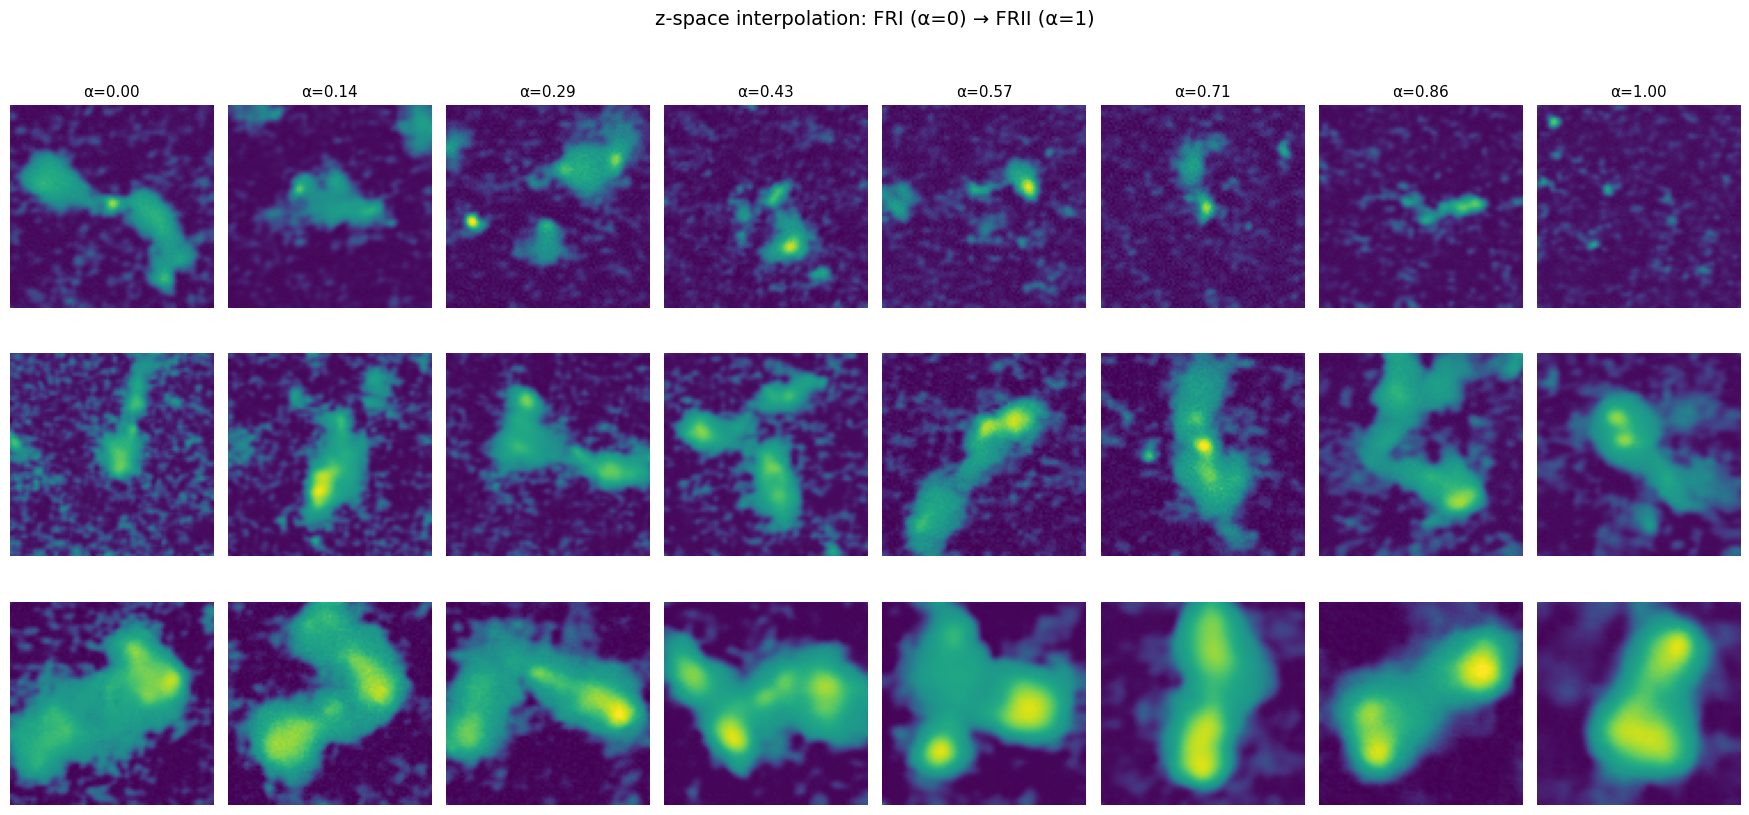

In [34]:
if n_labels >= 2:
    name_a, name_b = label_names_subset[0], label_names_subset[1]
    label_a = [0.0] * n_labels;  label_a[0] = 1.0
    label_b = [0.0] * n_labels;  label_b[1] = 1.0

    ya = torch.tensor([label_a], dtype=torch.float32, device=device)
    yb = torch.tensor([label_b], dtype=torch.float32, device=device)

    n_steps = 8
    n_rows  = 3
    alphas  = torch.linspace(0.0, 1.0, n_steps, device=device)

    # Sample n_rows independent (za, zb) pairs and decode all interpolations
    all_imgs = []
    with torch.no_grad():
        for _ in range(n_rows):
            za = flow(ya).sample()
            zb = flow(yb).sample()
            z_interp = torch.stack([(1 - a) * za + a * zb for a in alphas]).squeeze(1)
            decoder.eval()
            all_imgs.append(decoder.sample(z_interp, n_steps=FLOW_N_STEPS).cpu())

    fig, axes = plt.subplots(n_rows, n_steps, figsize=(2.2 * n_steps, 2.8 * n_rows))
    for row, imgs_interp in enumerate(all_imgs):
        for col, ax in enumerate(axes[row]):
            ax.imshow(imgs_interp[col, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
            if row == 0:
                ax.set_title(f"α={alphas[col]:.2f}", fontsize=11)
            ax.axis("off")
        axes[row, 0].set_ylabel(f"sample {row + 1}", fontsize=12, rotation=90,
                                labelpad=6, va='center')

    plt.suptitle(f"z-space interpolation: {name_a} (α=0) → {name_b} (α=1)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥ 2 labels for interpolation — skipping.")